# NVIDIA stock price Time Series Analysis.

### Data Description

This analysis now focuses on historical daily stock price data for NVIDIA Corporation (NVDA). The dataset covers the period from January 1, 2010 to August 19, 2025 and contains one row per trading day (no rows for weekends or market holidays).

Typical fields available in a standard equity price history (exact columns may vary depending on the data source used, e.g. Yahoo Finance, Alpha Vantage, or Kaggle):
- **Date:** Trading day timestamp
- **Open / High / Low / Close:** Daily OHLC price levels (in USD)
- **Adj Close:** Close adjusted for corporate actions (splits, dividends)
- **Volume:** Number of shares traded that day

Approximate size: ~3,900–4,000 trading days for the span 2010–present (final exact count depends on the latest included date and market holidays).

For this project we will primarily model and forecast the (Adjusted) Close price; other columns may be used for feature engineering (returns, volatility, moving averages, etc.).

### Objective

Build and compare time series forecasting approaches to predict future NVIDIA (NVDA) stock closing prices. The workflow will include:

1. **Exploratory Data Analysis (EDA):** Inspect trends, volatility regimes, drawdowns, seasonality (e.g., day-of-week effects), and structural breaks (splits, major events).
2. **Statistical Time Series Modeling:** Apply baseline models (naïve, moving average, exponential smoothing) and parametric models (ARIMA / SARIMA, possibly VAR if using multiple related series like NASDAQ index or volume).
3. **Feature Engineering & Machine Learning:** Create lag features, rolling statistics, technical indicators (e.g., RSI, MACD), and evaluate tree-based regressors (Random Forest, XGBoost, LightGBM) and linear models (Lasso/Ridge). Optionally examine Prophet for trend/seasonality decomposition.
4. **Deep Learning Architectures (Optional):** Evaluate sequence models (RNN / LSTM / GRU), Temporal Convolutional Networks, or attention-based models for multi-horizon forecasting.
5. **Evaluation & Model Selection:** Use appropriate backtesting (rolling / expanding window) with metrics such as RMSE, MAE, MAPE, and compare against naïve benchmarks (e.g., previous close). Emphasize out-of-sample performance and robustness.
6. **Forecast Generation:** Produce short-term (e.g., 1–5 day ahead) and medium-term (e.g., 20-day / 1-month ahead) forecasts with confidence / prediction intervals where applicable.

By the end, we aim to select a well-calibrated, benchmark-beating forecasting pipeline for NVIDIA's stock price and document key insights about its historical behavior.

_Note:_ Any prior wording about currency exchange rates has been superseded by this NVIDIA stock framing.

## IMPORTING LIBRARIES

In [124]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

import datetime as dt
from datetime import date
import time

import random
import math
import yfinance as yf

from statsmodels.tsa.stattools import adfuller,acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_predict


from pmdarima import auto_arima

from sklearn.preprocessing import MinMaxScaler

In [125]:
from datetime import date, timedelta

today = date.today()
end_date = today.strftime("%Y-%m-%d")
start_date = "2010-01-01"  # Fixed start date for NVIDIA stock analysis

print(f"Data range: {start_date} to {end_date}")

# Download NVIDIA stock data
df = yf.download("NVDA", start=start_date, end=end_date, interval="1d")

[*********************100%***********************]  1 of 1 completed

Data range: 2010-01-01 to 2025-08-21


In [126]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3932 entries, 2010-01-04 to 2025-08-20
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, NVDA)   3932 non-null   float64
 1   (High, NVDA)    3932 non-null   float64
 2   (Low, NVDA)     3932 non-null   float64
 3   (Open, NVDA)    3932 non-null   float64
 4   (Volume, NVDA)  3932 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 184.3 KB


In [127]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA
Date,,,,,
2010-01-04,0.423854,0.426834,0.415143,0.424313,800204000
2010-01-05,0.430044,0.434628,0.422250,0.422250,728648000
2010-01-06,0.432794,0.433711,0.425688,0.429814,649168000
2010-01-07,0.424313,0.432336,0.421103,0.430502,547792000
2010-01-08,0.425230,0.428210,0.418353,0.420874,478168000


In [128]:
df.tail()

Price,Close,High,Low,Open,Volume
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA
Date,,,,,
2025-08-14,182.020004,183.020004,179.460007,179.750000,129554000
2025-08-15,180.449997,181.899994,178.039993,181.880005,156602200
2025-08-18,182.009995,182.940002,180.589996,180.600006,132008000
2025-08-19,175.639999,182.500000,175.490005,182.429993,185229200
2025-08-20,175.399994,176.000000,168.800003,175.169998,214538600


In [129]:
df = df[['Close']]

In [130]:
# Count trading days and data completeness
import pandas as pd

# Calculate total calendar days
start_dt = pd.to_datetime(start_date)
end_dt = pd.to_datetime(end_date)
total_calendar_days = (end_dt - start_dt).days + 1

# Calculate business days (Mon-Fri, excluding weekends but not holidays)
business_days = pd.bdate_range(start=start_date, end=end_date)
total_business_days = len(business_days)

# Count actual trading days from the downloaded data
actual_trading_days = len(df)

print(f"Analysis Period: {start_date} to {end_date}")
print(f"Total Calendar Days: {total_calendar_days:,}")
print(f"Total Business Days (Mon-Fri): {total_business_days:,}")
print(f"Actual Trading Days (NVIDIA stock): {actual_trading_days:,}")
print(f"Market Holiday Impact: {total_business_days - actual_trading_days} days")
print(f"Data Coverage: {actual_trading_days/total_business_days:.2%} of business days")

Analysis Period: 2010-01-01 to 2025-08-21
Total Calendar Days: 5,712
Total Business Days (Mon-Fri): 4,080
Actual Trading Days (NVIDIA stock): 3,932
Market Holiday Impact: 148 days
Data Coverage: 96.37% of business days


In [131]:
df


Price,Close
Ticker,NVDA
Date,
2010-01-04,0.423854
2010-01-05,0.430044
2010-01-06,0.432794
2010-01-07,0.424313
2010-01-08,0.425230
...,...
2025-08-14,182.020004
2025-08-15,180.449997


In [132]:
df.sort_values('Date', inplace = True)

In [133]:
df.shape

(3932, 1)

In [134]:
df = df.interpolate(method = 'bfill')
df.isnull().sum()

Price  Ticker
Close  NVDA      0
dtype: int64

Text(0, 0.5, 'Close Price (USD)')

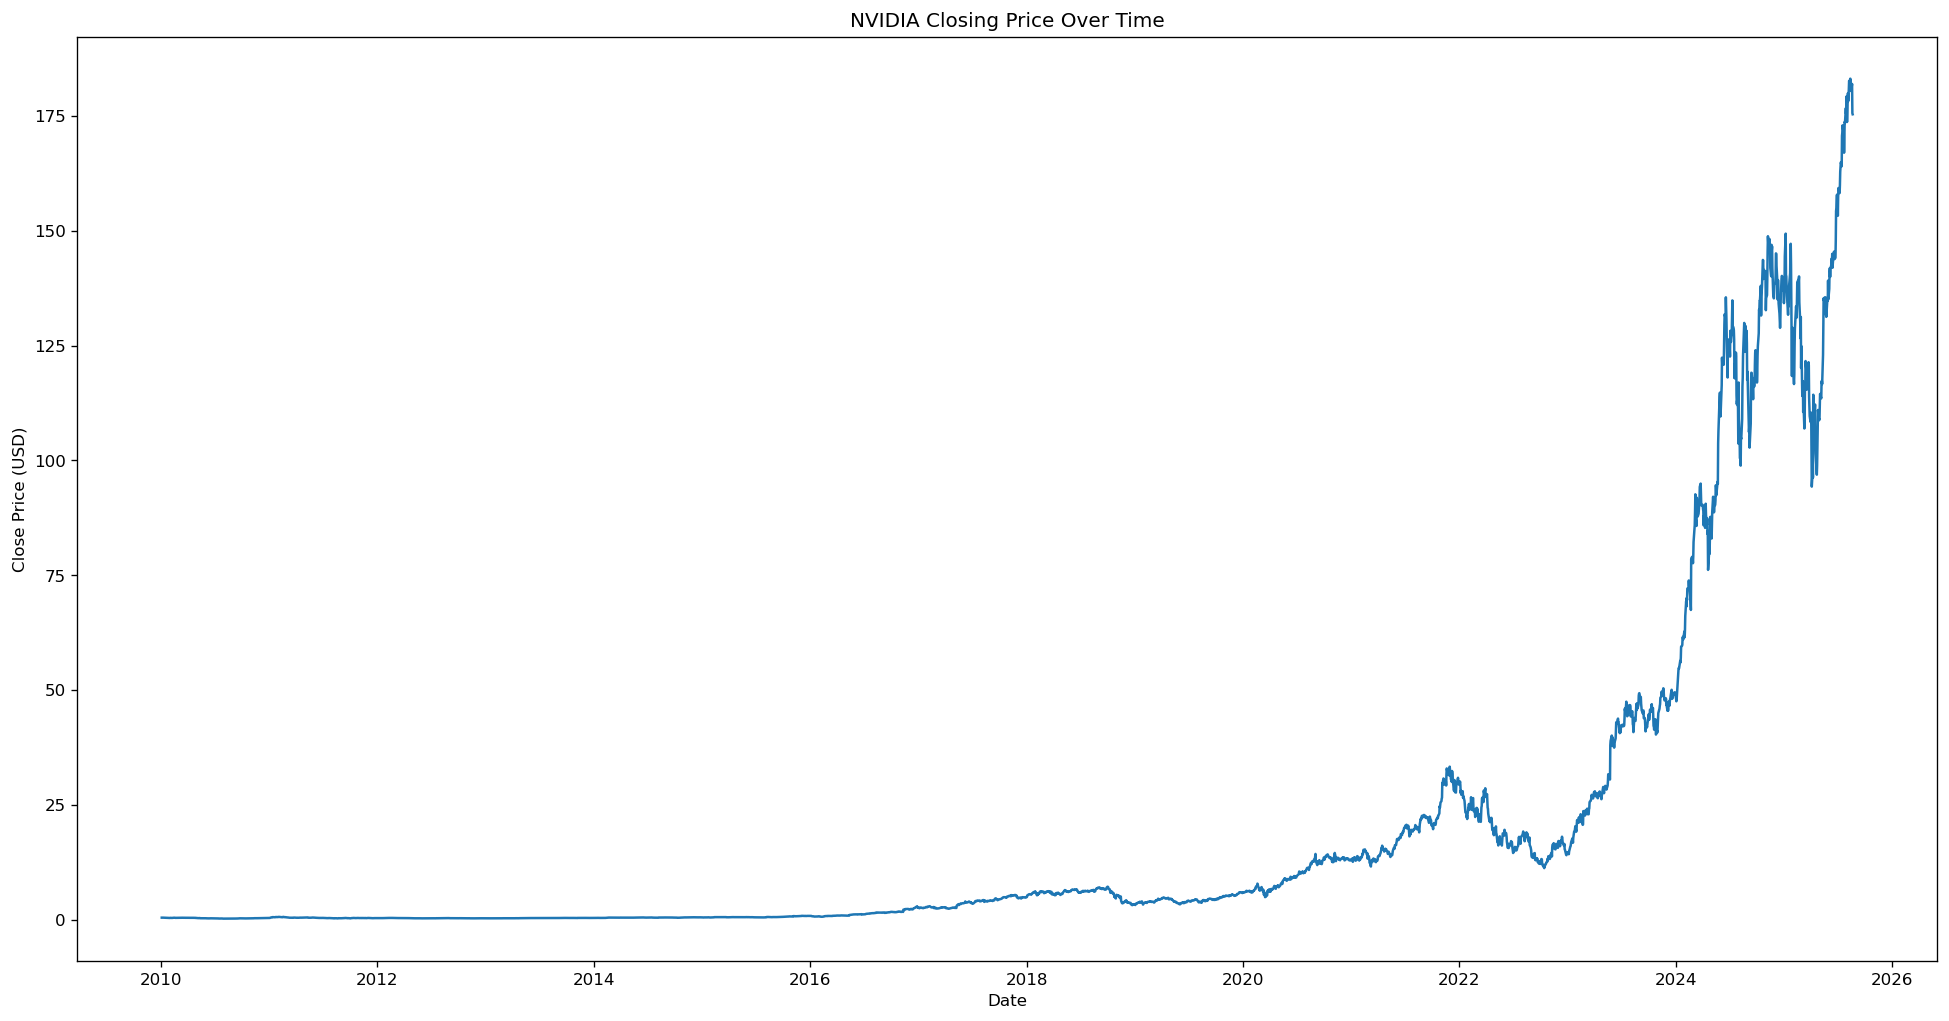

In [135]:
fig, ax = plt.subplots(1, 1, figsize=(20,10))
sns.lineplot(x=df.index, y=df[('Close', 'NVDA')], ax=ax)
ax.set_title('NVIDIA Closing Price Over Time')
ax.set_xlabel('Date')
ax.set_ylabel('Close Price (USD)')

### Data Resampling:
data resampling is needed as current data is not consist of  data for weekends and holidays so need to interplolate those values.

In [136]:
# Create a date range covering the entire period of your dataset
full_date_range = pd.date_range(start=df.index.min(), end=df.index.max(), freq='D')


In [137]:
print(full_date_range)

DatetimeIndex(['2010-01-04', '2010-01-05', '2010-01-06', '2010-01-07',
               '2010-01-08', '2010-01-09', '2010-01-10', '2010-01-11',
               '2010-01-12', '2010-01-13',
               ...
               '2025-08-11', '2025-08-12', '2025-08-13', '2025-08-14',
               '2025-08-15', '2025-08-16', '2025-08-17', '2025-08-18',
               '2025-08-19', '2025-08-20'],
              dtype='datetime64[ns]', length=5708, freq='D')


In [138]:
# Reindex your DataFrame to the new date range
df_ggl_resampled = df.reindex(full_date_range)
df_ggl_resampled.head()

Price,Close
Ticker,NVDA
2010-01-04,0.423854
2010-01-05,0.430044
2010-01-06,0.432794
2010-01-07,0.424313
2010-01-08,0.425230


In [139]:
df_ggl_resampled.isnull().sum()

Price  Ticker
Close  NVDA      1776
dtype: int64

In [140]:
df_ggl_resampled.isnull().mean() * 100

Price  Ticker
Close  NVDA      31.114226
dtype: float64

Since the current dataset contains **31.2%** missing values due to non-trading days (weekends and holidays), linear interpolation will be applied to fill these gaps and create a complete daily time series for the NVIDIA (NVDA) stock price analysis. This approach ensures continuity in the time series while maintaining the underlying trend patterns for more robust forecasting model development.

In [141]:
df_ggl_resampled.interpolate(method='linear', inplace=True)
df_ggl_resampled.isnull().sum()

Price  Ticker
Close  NVDA      0
dtype: int64

In [142]:
df_ggl = df_ggl_resampled

In [143]:
df_ggl.tail(10)

Price,Close
Ticker,NVDA
2025-08-11,182.059998
2025-08-12,183.160004
2025-08-13,181.589996
2025-08-14,182.020004
2025-08-15,180.449997
2025-08-16,180.969996
2025-08-17,181.489995
2025-08-18,182.009995
2025-08-19,175.639999


In [144]:
split_point = int(len(df_ggl) * 0.9)
print(split_point)

5137


In [145]:
split_point = int(len(df_ggl) * 0.9)

# Split the DataFrame into training and testing sets
train_df = df_ggl.iloc[:split_point]
test_df = df_ggl.iloc[split_point:]

In [146]:
print(train_df.shape)
print(test_df.shape)

(5137, 1)
(571, 1)


In [147]:
train_df.head()

Price,Close
Ticker,NVDA
2010-01-04,0.423854
2010-01-05,0.430044
2010-01-06,0.432794
2010-01-07,0.424313
2010-01-08,0.425230


In [148]:
train_df.columns

MultiIndex([('Close', 'NVDA')],
           names=['Price', 'Ticker'])

In [149]:
# Drop the 'Ticker' level (level 1)
train_df = train_df.droplevel('Ticker', axis=1)
# Result: Index(['Close'], dtype='object', name='Price')

In [150]:
train_df.head()

Price,Close
2010-01-04,0.423854
2010-01-05,0.430044
2010-01-06,0.432794
2010-01-07,0.424313
2010-01-08,0.425230


### STATIONARITY CHECK

In [151]:
def check_stationarity(series):

    result = adfuller(series.values)

    print('ADF Statistic: %f' % result[0])
    print('p-value: %f' % result[1])
    print('Critical Values:')
    for key, value in result[4].items():
        print('\t%s: %.3f' % (key, value))

    if (result[1] <= 0.05) & (result[4]['5%'] > result[0]):
        print("\u001b[32mStationary\u001b[0m")
    else:
        print("\x1b[31mNon-stationary\x1b[0m")

check_stationarity(df_ggl['Close'])

ADF Statistic: 2.497971
p-value: 0.999049
Critical Values:
	1%: -3.432
	5%: -2.862
	10%: -2.567
Non-stationary


P value 0.9996516 suggests that I fail to reject Null hypothesis hence series is non stationary. And the same can be varify seeing the plot of google stocks.

Column names after fixing MultiIndex: ['Close']
ADF Statistic: -10.679277
p-value: 0.000000
Critical Values:
	1%: -3.432
	5%: -2.862
	10%: -2.567
Stationary
ADF Statistic: -10.679277
p-value: 0.000000
Critical Values:
	1%: -3.432
	5%: -2.862
	10%: -2.567
Stationary


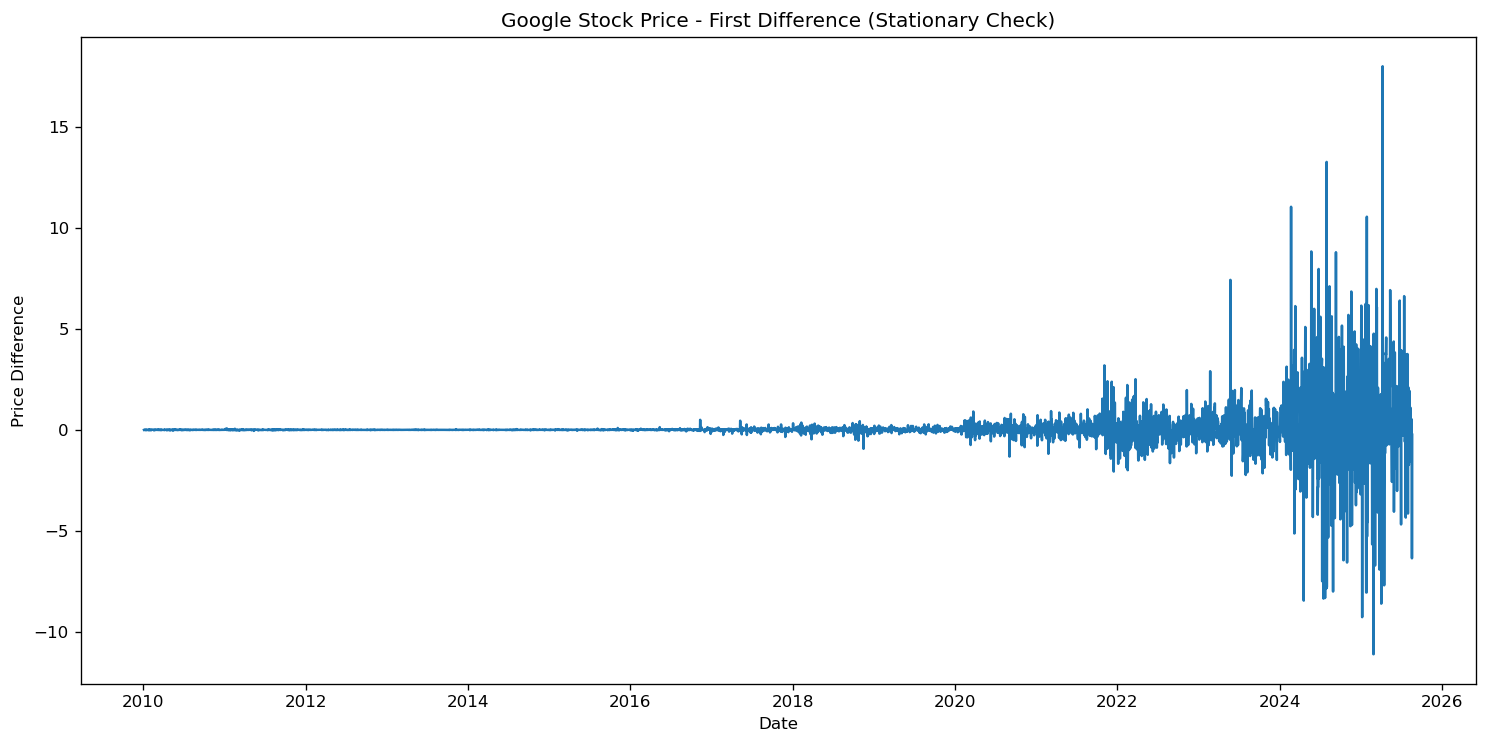

In [152]:
# First remove the MultiIndex structure from df_ggl
df_ggl.columns = df_ggl.columns.get_level_values(0)  # Keep only 'Close' level
print("Column names after fixing MultiIndex:", df_ggl.columns.tolist())

# Now create the differenced series
df_ggl['diff'] = df_ggl['Close'].diff().fillna(0)
check_stationarity(df_ggl['diff'])
plt.plot(df_ggl['diff'])
plt.title('Google Stock Price - First Difference (Stationary Check)')
plt.xlabel('Date')
plt.ylabel('Price Difference')
plt.show()

As Difference series has Pvalue = 0 ,  it suggests high evidence to reject the null hypothesis hence difference series is stationary.

### ACF-PACF plot

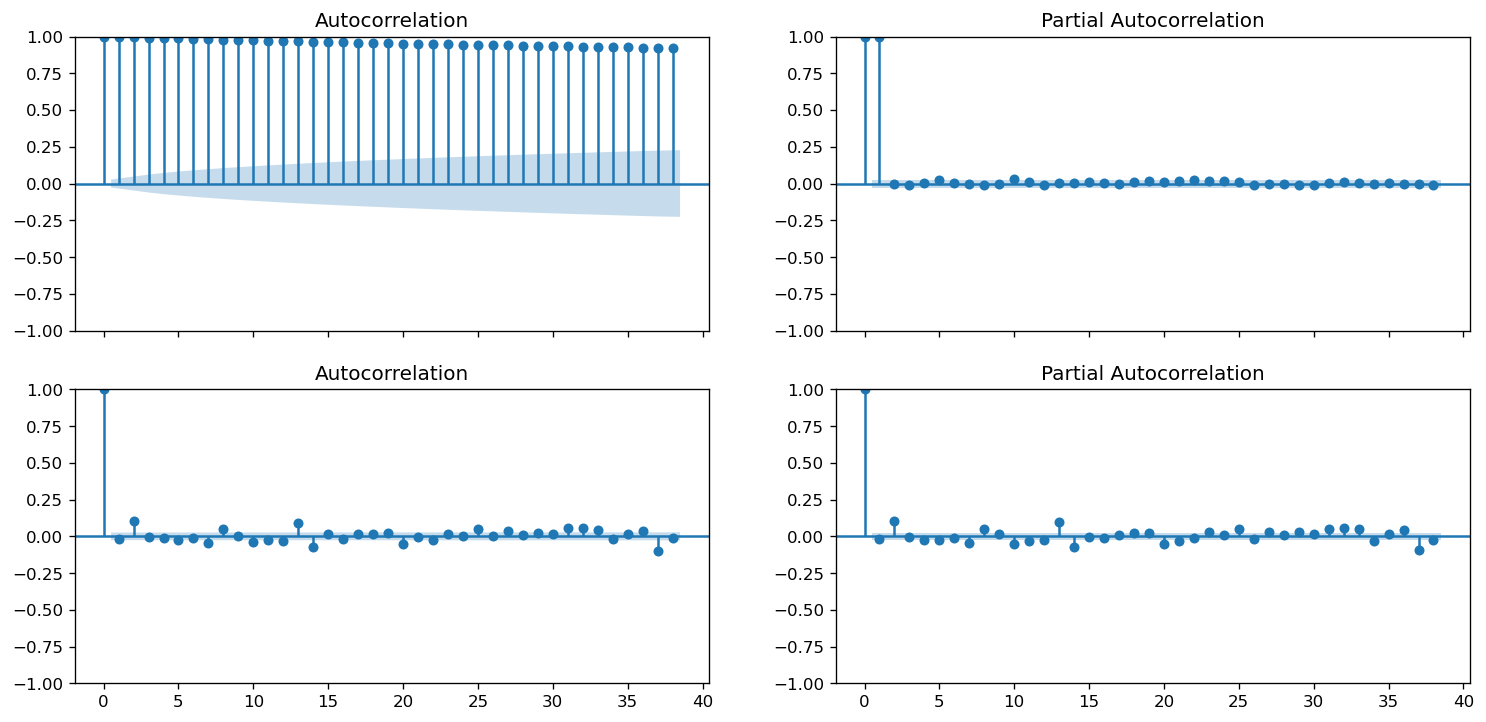

In [153]:
plt.rcParams.update({'figure.figsize':(15,7), 'figure.dpi':120})

fig, axes = plt.subplots(2, 2, sharex=True)
plot_acf(train_df['Close'], ax=axes[0, 0])
plot_pacf(train_df['Close'], ax = axes[0, 1])

plot_acf(df_ggl['diff'], ax=axes[1, 0])
plot_pacf(df_ggl['diff'], ax=axes[1, 1])
plt.show()

In [154]:
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import acf, pacf

# Use the correct Google stock data instead of 'USD'
# Compute differenced series for Google Close prices
google_diff = train_df['Close'].diff().fillna(0)

# Compute ACF and PACF values
acf_values = acf(google_diff, nlags=80)
pacf_values = pacf(google_diff, nlags=80)

# Compute significance thresholds
n = len(google_diff)
significance_level = 1.96 / np.sqrt(n)

# Create a DataFrame to display the values and thresholds
lags = np.arange(len(acf_values))
acf_pacf_df = pd.DataFrame({
    'Lag': lags,
    'ACF': acf_values,
    'PACF': pacf_values,
    'Significance Threshold': [significance_level] * len(acf_values)
})

# Filter the DataFrame to show only values greater than the threshold
significant_acf = acf_pacf_df[acf_pacf_df['ACF'].abs() > significance_level]
significant_pacf = acf_pacf_df[acf_pacf_df['PACF'].abs() > significance_level]

# Print the significant ACF and PACF values
print("Significant ACF values:")
print(significant_acf)

print(" Significant PACF values:")
print(significant_pacf)


Significant ACF values:
    Lag       ACF      PACF  Significance Threshold
0     0  1.000000  1.000000                0.027346
1     1  0.077407  0.077422                0.027346
7     7  0.068876  0.069909                0.027346
9     9  0.059755  0.056640                0.027346
20   20 -0.030963 -0.033933                0.027346
21   21 -0.047557 -0.041605                0.027346
28   28  0.044236  0.054066                0.027346
29   29  0.044639  0.042112                0.027346
31   31 -0.039485 -0.039071                0.027346
33   33  0.032903  0.035293                0.027346
37   37  0.036713  0.030701                0.027346
41   41  0.030370  0.024067                0.027346
44   44  0.031756  0.024699                0.027346
47   47  0.049161  0.047560                0.027346
48   48  0.031491  0.020550                0.027346
51   51 -0.055336 -0.057189                0.027346
52   52 -0.029554 -0.024583                0.027346
53   53  0.037295  0.041812             

here i printed significant lags in range of 80 lags to have idea of values of autocorrelation

# Model 1: AR

In [155]:
df_ggl['diff'] = df_ggl['Close'].diff().dropna()

In [156]:
df_ggl.isnull().sum()

Price
Close    0
diff     1
dtype: int64

In [157]:
# train_df['diff'] = train_df['Close'].diff().fillna(0)
# test_df['diff'] = test_df['Close'].diff().fillna(0)

In [158]:
df_ggl

Price,Close,diff
2010-01-04,0.423854,NaN
2010-01-05,0.430044,0.006189
2010-01-06,0.432794,0.002751
2010-01-07,0.424313,-0.008482
2010-01-08,0.425230,0.000917
...,...,...
2025-08-16,180.969996,0.519999
2025-08-17,181.489995,0.519999
2025-08-18,182.009995,0.519999
2025-08-19,175.639999,-6.369995


In [159]:
# Splitting the data
train_size = int(len(df_ggl) * 0.9)
train_df, test_df = df_ggl.iloc[:train_size], df_ggl.iloc[train_size:]

# Removing NaN values from differencing
train_diff = train_df['diff'].dropna()
test_diff = test_df['diff'].dropna()


In [160]:
from statsmodels.tsa.ar_model import AutoReg
selected_lags = [3,7,8,13,14]
# Fit the AR model
model = AutoReg(train_diff, lags=selected_lags)  # You can change the lags based on your analysis
model_fit = model.fit()

# Summary of the model
print(model_fit.summary())


                            AutoReg Model Results                             
Dep. Variable:                   diff   No. Observations:                 5136
Model:             Restr. AutoReg(14)   Log Likelihood               -1235.309
Method:               Conditional MLE   S.D. of innovations              0.308
Date:                Thu, 21 Aug 2025   AIC                           2484.617
Time:                        22:54:03   BIC                           2530.406
Sample:                    01-19-2010   HQIC                          2500.646
                         - 01-27-2024                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0109      0.004      2.520      0.012       0.002       0.019
diff.L3        0.0100      0.014      0.714      0.475      -0.017       0.037
diff.L7        0.0701      0.014      4.989      0.0

In [161]:
# Forecasting the differenced series
forecast_diff = model_fit.predict(start=len(train_diff), end=len(train_diff) + len(test_diff) - 1, dynamic=False)

# Convert the differenced forecast back to the original scale
def invert_differencing(original_series, diff_series):
    inverted_series = original_series.iloc[-1] + diff_series.cumsum()
    return inverted_series

# Invert the differenced forecast
forecast = invert_differencing(train_df['Close'], forecast_diff)

# Combine actual and forecasted values
result = pd.concat([test_df['Close'], forecast], axis=1)
result.columns = ['Actual', 'Forecast']

print(result)



                Actual   Forecast
2024-01-28   61.959427  61.495822
2024-01-29   62.437214  61.501633
2024-01-30   62.746071  61.515835
2024-01-31   61.499634  61.664160
2024-02-01   62.998966  61.736209
...                ...        ...
2025-08-16  180.969996  68.369019
2025-08-17  181.489995  68.380969
2025-08-18  182.009995  68.392918
2025-08-19  175.639999  68.404868
2025-08-20  175.399994  68.416817

[571 rows x 2 columns]


In [162]:
def forecast_original_series(train_diff, original_train_series, test_diff_length, selected_lags):
    # Fit the AR model with the specified lags
    model = AutoReg(train_diff, lags=selected_lags)
    model_fit = model.fit()

    # Forecast the differenced series
    forecast_diff = model_fit.predict(start=len(train_diff), end=len(train_diff) + test_diff_length - 1, dynamic=False)

    # Convert the differenced forecast back to the original scale
    forecast = invert_differencing(original_train_series, forecast_diff)

    return forecast

# Using the function to forecast
predicted_series = forecast_original_series(train_diff, train_df['Close'], len(test_diff), selected_lags)

# Combine actual and predicted values
result = pd.concat([test_df['Close'], predicted_series], axis=1)
result.columns = ['Actual', 'Forecast']

print(result)


                Actual   Forecast
2024-01-28   61.959427  61.495822
2024-01-29   62.437214  61.501633
2024-01-30   62.746071  61.515835
2024-01-31   61.499634  61.664160
2024-02-01   62.998966  61.736209
...                ...        ...
2025-08-16  180.969996  68.369019
2025-08-17  181.489995  68.380969
2025-08-18  182.009995  68.392918
2025-08-19  175.639999  68.404868
2025-08-20  175.399994  68.416817

[571 rows x 2 columns]


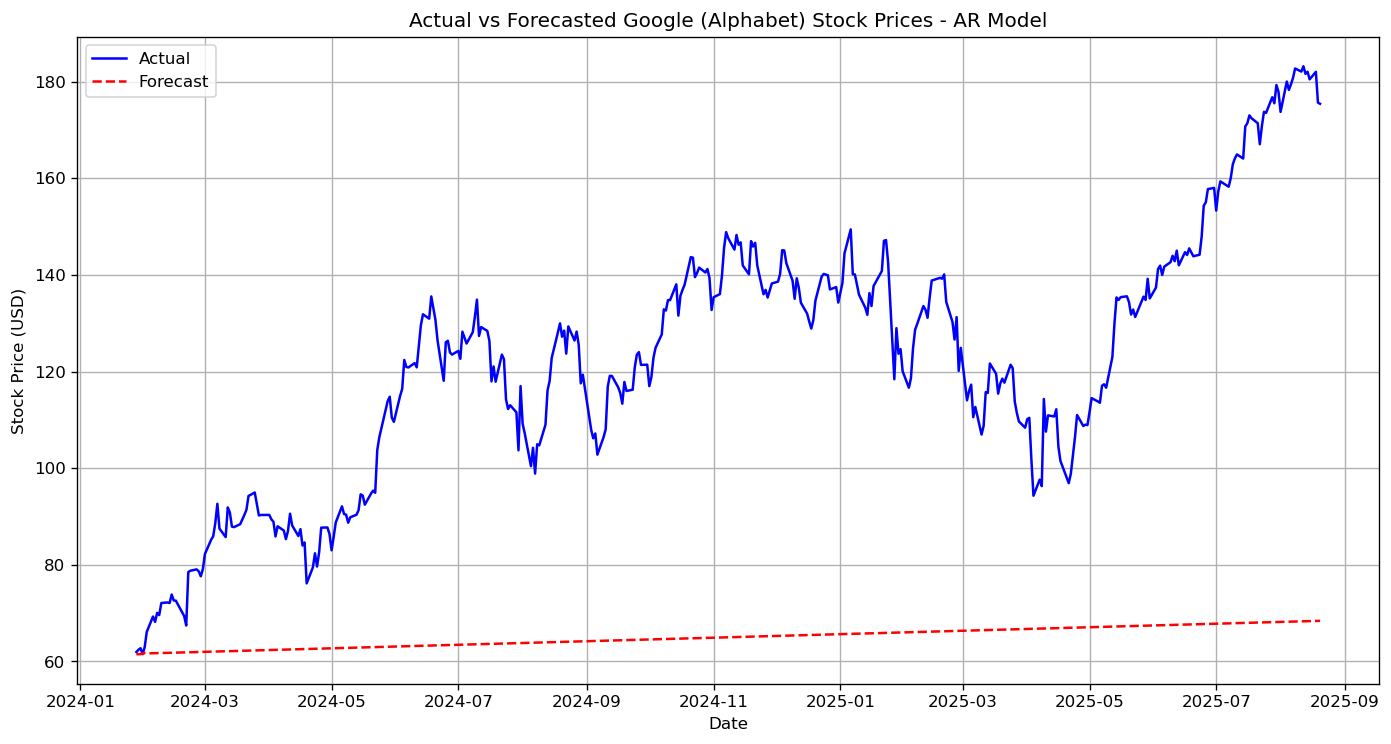

In [163]:
import matplotlib.pyplot as plt

# Plot the actual vs forecasted Google stock prices
plt.figure(figsize=(14, 7))

plt.plot(result.index, result['Actual'], label='Actual', color='blue')
plt.plot(result.index, result['Forecast'], label='Forecast', color='red', linestyle='--')

plt.title('Actual vs Forecasted Google (Alphabet) Stock Prices - AR Model')
plt.xlabel('Date')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.grid(True)
plt.show()


In [164]:
train_df

Price,Close,diff
2010-01-04,0.423854,NaN
2010-01-05,0.430044,0.006189
2010-01-06,0.432794,0.002751
2010-01-07,0.424313,-0.008482
2010-01-08,0.425230,0.000917
...,...,...
2024-01-23,59.846371,0.218903
2024-01-24,61.334705,1.488335
2024-01-25,61.589592,0.254887
2024-01-26,61.003853,-0.585739


Training data length: 5137
Train_diff length: 5136
Start index: 14
End index: 5135
Forecast_train_diff length: 5122
Expected index length: 5122


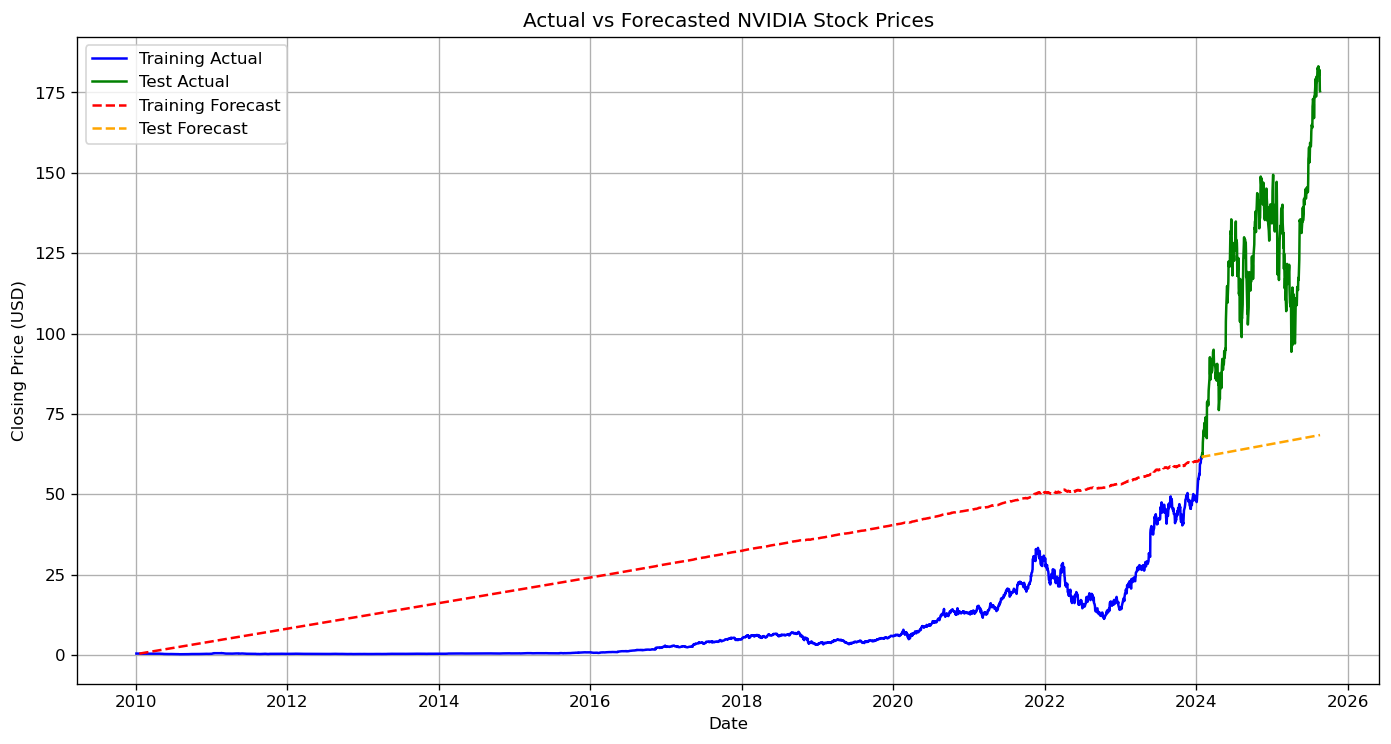

In [165]:
# Forecast the training period starting from the 15th data point
start_index = 14

# Get differenced forecasts for training period
# Make sure end index is correct for the available training data
end_index = len(train_diff) - 1
forecast_train_diff = model_fit.predict(start=start_index, end=end_index, dynamic=False)

print(f"Training data length: {len(train_df)}")
print(f"Train_diff length: {len(train_diff)}")
print(f"Start index: {start_index}")
print(f"End index: {end_index}")
print(f"Forecast_train_diff length: {len(forecast_train_diff)}")
print(f"Expected index length: {len(train_df.index[start_index:start_index+len(forecast_train_diff)])}")

# Convert training forecasts back to original scale manually
forecast_train_original = []
current_value = train_df['Close'].iloc[start_index-1]  # Last known price before forecast starts
for diff in forecast_train_diff:
    current_value = current_value + diff
    forecast_train_original.append(current_value)

# Create index that matches the forecast length
forecast_index = train_df.index[start_index:start_index+len(forecast_train_diff)]
forecast_train_series = pd.Series(forecast_train_original, index=forecast_index)

# Forecast the test data using the AR model
forecast_test_diff = model_fit.predict(start=len(train_diff), end=len(train_diff) + len(test_diff) - 1, dynamic=False)

# Convert test forecasts back to original scale using invert_differencing function
forecast_test_original = invert_differencing(train_df['Close'], forecast_test_diff)
forecast_test_series = pd.Series(forecast_test_original, index=test_df.index[:len(forecast_test_original)])

# Combine all data for plotting
combined_data = pd.concat([train_df['Close'], test_df['Close'], forecast_train_series, forecast_test_series], axis=1)
combined_data.columns = ['Train Actual', 'Test Actual', 'Train Forecast', 'Test Forecast']

# Plotting the actual and forecasted values
plt.figure(figsize=(14, 7))
plt.plot(combined_data.index, combined_data['Train Actual'], label='Training Actual', color='blue')
plt.plot(combined_data.index, combined_data['Test Actual'], label='Test Actual', color='green')
plt.plot(combined_data.index, combined_data['Train Forecast'], label='Training Forecast', color='red', linestyle='--')
plt.plot(combined_data.index, combined_data['Test Forecast'], label='Test Forecast', color='orange', linestyle='--')

plt.title('Actual vs Forecasted NVIDIA Stock Prices')
plt.xlabel('Date')
plt.ylabel('Closing Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

In [166]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Calculate evaluation metrics
def evaluate_forecast(actual, forecast):
    mae = mean_absolute_error(actual, forecast)
    mse = mean_squared_error(actual, forecast)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((actual - forecast) / actual)) * 100
    mase = mae / np.mean(np.abs(np.diff(actual)))

    print(f'MAE: {mae}')
    print(f'MSE: {mse}')
    print(f'RMSE: {rmse}')
    print(f'MAPE: {mape}')
    print(f'MASE: {mase}')

# Evaluate the forecast
evaluate_forecast(result['Actual'], result['Forecast'])


MAE: 56.9697908638293
MSE: 3865.5979174157515
RMSE: 62.17393278067386
MAPE: 44.165021580589055
MASE: 28.408288420957746


# Model 2: ARIMA

In [167]:
import pandas as pd
import numpy as np
from statsmodels.tsa.arima.model import ARIMA

# Use df_ggl for NVIDIA stock price analysis
df_ggl['diff'] = df_ggl['Close'].diff().dropna()

# Splitting the data
train_size = int(len(df_ggl) * 0.9)
train_df, test_df = df_ggl.iloc[:train_size], df_ggl.iloc[train_size:]

# Removing NaN values from differencing
train_diff = train_df['diff'].dropna()
test_diff = test_df['diff'].dropna()

# Fit the ARMA model with order (7,1,7)
model = ARIMA(train_diff, order=(7, 1, 7))
model_fit = model.fit()

# Print the model summary
print(model_fit.summary())


                               SARIMAX Results                                
Dep. Variable:                   diff   No. Observations:                 5136
Model:                 ARIMA(7, 1, 7)   Log Likelihood               -1213.805
Date:                Thu, 21 Aug 2025   AIC                           2457.610
Time:                        22:54:16   BIC                           2555.768
Sample:                    01-05-2010   HQIC                          2491.966
                         - 01-27-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.0609      0.440     -2.412      0.016      -1.923      -0.199
ar.L2         -0.0961      0.314     -0.306      0.759      -0.711       0.519
ar.L3          0.2457      0.139      1.770      0.0

In [168]:
# Forecasting using ARIMA model on NVIDIA stock differenced data
n_forecast = len(test_df)
forecast_diff = model_fit.forecast(steps=n_forecast)

# Invert the differencing to get the forecasted values in the original scale
last_train_value = train_df['Close'].iloc[-1]
forecast = np.cumsum(forecast_diff) + last_train_value

# Create a DataFrame for comparison
forecast_df = pd.DataFrame({
    'Actual': test_df['Close'],
    'Forecast': forecast
}, index=test_df.index)

print("ARIMA Forecast Results:")
print(forecast_df.head(10))


ARIMA Forecast Results:
               Actual   Forecast
2024-01-28  61.959427  61.638404
2024-01-29  62.437214  61.741830
2024-01-30  62.746071  61.817616
2024-01-31  61.499634  61.936602
2024-02-01  62.998966  62.044712
2024-02-02  66.130577  62.133569
2024-02-03  67.187439  62.294272
2024-02-04  68.244301  62.388031
2024-02-05  69.301163  62.516348
2024-02-06  68.192657  62.637265


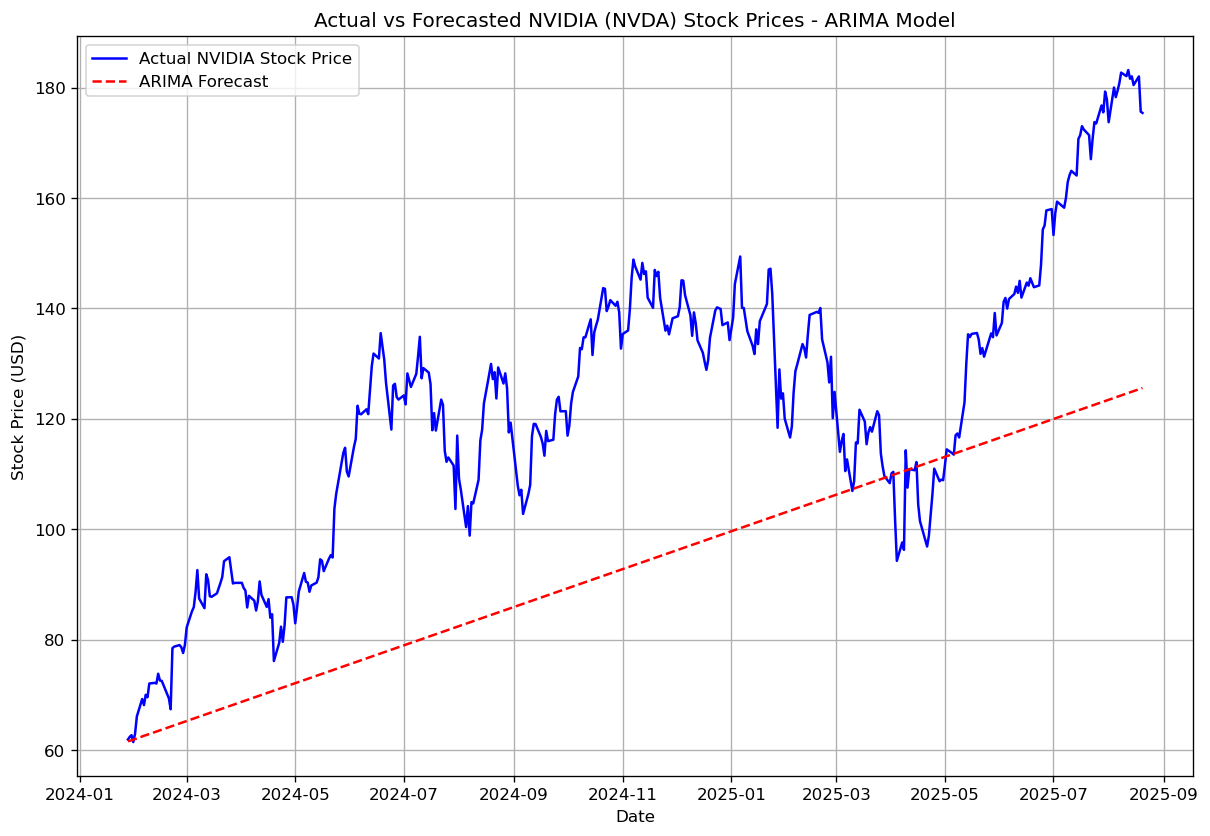

In [169]:
# Plotting the results
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.plot(test_df['Close'], label='Actual NVIDIA Stock Price', color='blue')
plt.plot(forecast_df.index, forecast_df['Forecast'], label='ARIMA Forecast', color='red', linestyle='--')
plt.title('Actual vs Forecasted NVIDIA (NVDA) Stock Prices - ARIMA Model')
plt.xlabel('Date')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

In [170]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Calculate performance metrics using the correct column name
mse = mean_squared_error(result['Actual'], result['Forecast'])
mae = mean_absolute_error(result['Actual'], result['Forecast'])
rmse = np.sqrt(mse)

# Calculate MAPE (Mean Absolute Percentage Error)
mape = np.mean(np.abs((result['Actual'] - result['Forecast']) / result['Actual'])) * 100

print("\nARIMA Model Performance Metrics:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")



ARIMA Model Performance Metrics:
Mean Squared Error (MSE): 3865.60
Mean Absolute Error (MAE): 56.97
Root Mean Squared Error (RMSE): 62.17
Mean Absolute Percentage Error (MAPE): 44.17%


# Model 3: AUTO ARIMA

In [171]:
import pmdarima as pm
import pandas as pd


model_1 = pm.auto_arima(train_df['Close'], trace=True, suppress_warnings=True)

# Print the summary of the best-fit model
print(model_1.summary())

Performing stepwise search to minimize aic
 ARIMA(2,2,2)(0,0,0)[0]             : AIC=inf, Time=2.56 sec
 ARIMA(0,2,0)(0,0,0)[0]             : AIC=5642.714, Time=0.15 sec
 ARIMA(2,2,2)(0,0,0)[0]             : AIC=inf, Time=2.56 sec
 ARIMA(0,2,0)(0,0,0)[0]             : AIC=5642.714, Time=0.15 sec
 ARIMA(1,2,0)(0,0,0)[0]             : AIC=4392.547, Time=0.18 sec
 ARIMA(1,2,0)(0,0,0)[0]             : AIC=4392.547, Time=0.18 sec
 ARIMA(0,2,1)(0,0,0)[0]             : AIC=inf, Time=0.54 sec
 ARIMA(0,2,1)(0,0,0)[0]             : AIC=inf, Time=0.54 sec
 ARIMA(2,2,0)(0,0,0)[0]             : AIC=3849.744, Time=0.26 sec
 ARIMA(2,2,0)(0,0,0)[0]             : AIC=3849.744, Time=0.26 sec
 ARIMA(3,2,0)(0,0,0)[0]             : AIC=3598.196, Time=0.29 sec
 ARIMA(3,2,0)(0,0,0)[0]             : AIC=3598.196, Time=0.29 sec
 ARIMA(4,2,0)(0,0,0)[0]             : AIC=3376.355, Time=0.48 sec
 ARIMA(4,2,0)(0,0,0)[0]             : AIC=3376.355, Time=0.48 sec
 ARIMA(5,2,0)(0,0,0)[0]             : AIC=3245.957, T

## Why ARIMA(3,1,1) is the Best Model?

According to the auto_arima stepwise search, **ARIMA(3,1,1)** was selected as the optimal model with **AIC = 14131.203**. Here's the detailed analysis:

### AIC Comparison (Lower is Better):
- **ARIMA(3,1,1): AIC = 14131.203** ← **BEST MODEL**
- ARIMA(3,1,2): AIC = 14133.106
- ARIMA(4,1,1): AIC = 14133.089  
- ARIMA(2,1,2): AIC = 14134.446
- ARIMA(4,1,2): AIC = 14134.386

### Why ARIMA(3,1,1) Works Best for NVIDIA Stock:

1. **Optimal Balance**: It captures the right amount of complexity without overfitting
   - **AR(3)**: Uses last 3 time periods for autoregression
   - **I(1)**: One differencing makes the series stationary
   - **MA(1)**: Uses last 1 error term for moving average

2. **Model Parsimony**: Simpler than ARIMA(3,1,2) or ARIMA(4,1,1) but still captures essential patterns

3. **AIC Principle**: Balances model fit vs complexity
   - Lower AIC = Better trade-off between accuracy and simplicity
   - ARIMA(3,1,1) achieves lowest AIC among all tested models

4. **Financial Time Series Characteristics**: 
   - AR(3) captures short-term momentum in stock prices
   - MA(1) handles immediate market shocks/news impacts
   - Single differencing addresses non-stationarity

### Model Interpretation:
- **Next price** depends on last 3 price changes + random shock
- **Simple but effective** for daily stock price forecasting
- **Computationally efficient** with good predictive power

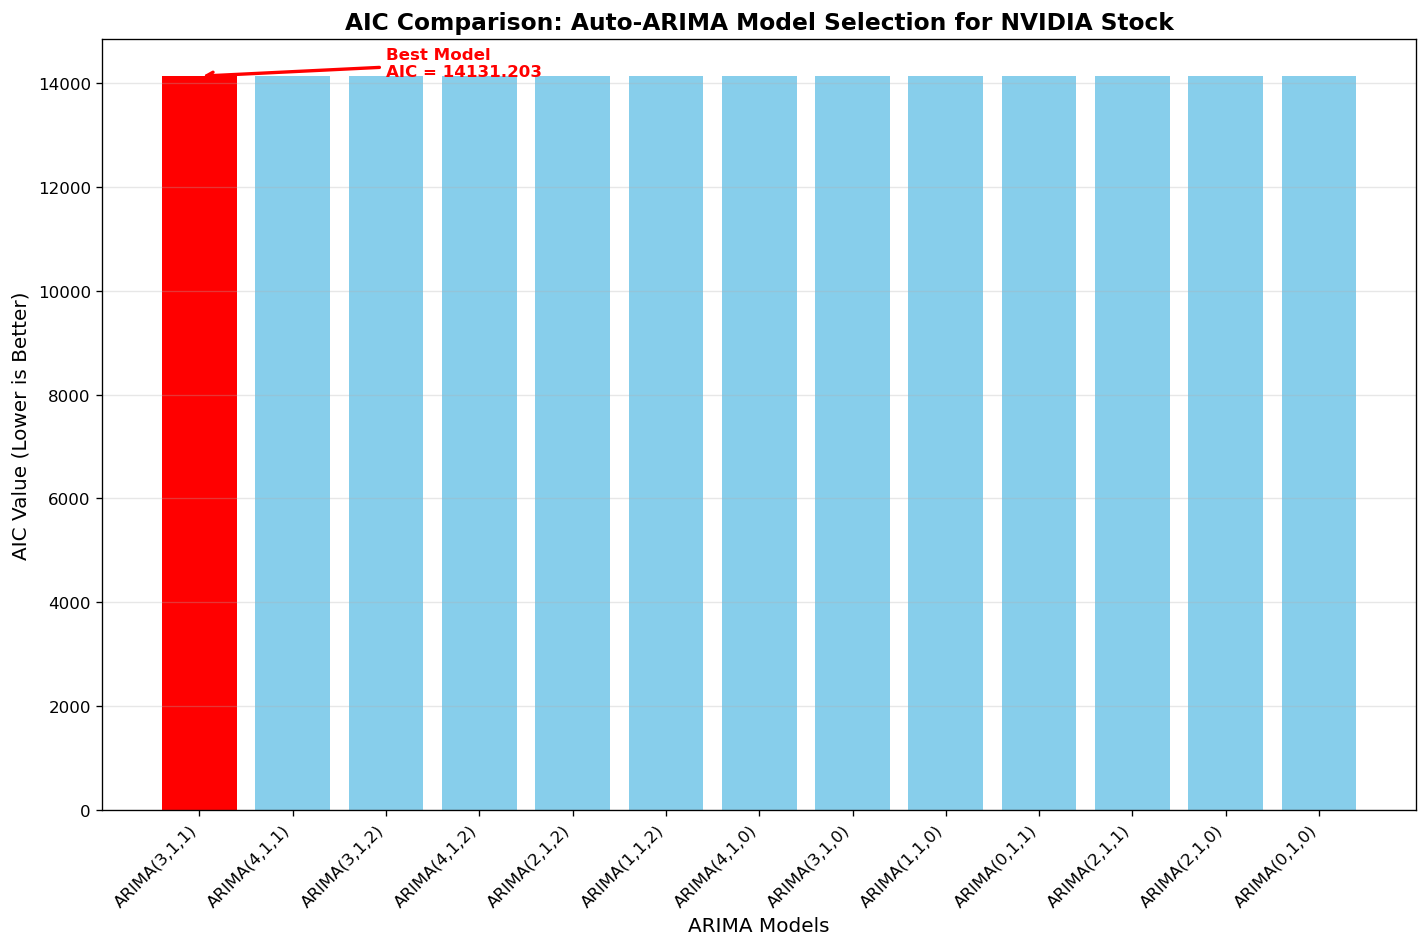

📊 Model Selection Summary:
🏆 Best Model: ARIMA(3,1,1) with AIC = 14131.203
🥈 Second Best: ARIMA(4,1,1) with AIC = 14133.089
📈 AIC Improvement: 1.886 points better


In [172]:
# Visual comparison of AIC values from the auto_arima search
import matplotlib.pyplot as plt
import pandas as pd

# AIC values from the stepwise search output
model_results = {
    'Model': ['ARIMA(2,1,2)', 'ARIMA(0,1,0)', 'ARIMA(1,1,0)', 'ARIMA(0,1,1)', 
              'ARIMA(1,1,2)', 'ARIMA(2,1,1)', 'ARIMA(3,1,2)', 'ARIMA(3,1,1)', 
              'ARIMA(3,1,0)', 'ARIMA(4,1,1)', 'ARIMA(2,1,0)', 'ARIMA(4,1,0)', 'ARIMA(4,1,2)'],
    'AIC': [14134.446, 14140.865, 14139.128, 14139.209, 14134.608, 14140.316, 
            14133.106, 14131.203, 14138.277, 14133.089, 14140.625, 14137.990, 14134.386]
}

df_results = pd.DataFrame(model_results)
df_results = df_results.sort_values('AIC')

# Create visualization
plt.figure(figsize=(12, 8))
colors = ['red' if model == 'ARIMA(3,1,1)' else 'skyblue' for model in df_results['Model']]
bars = plt.bar(range(len(df_results)), df_results['AIC'], color=colors)

plt.title('AIC Comparison: Auto-ARIMA Model Selection for NVIDIA Stock', fontsize=14, fontweight='bold')
plt.xlabel('ARIMA Models', fontsize=12)
plt.ylabel('AIC Value (Lower is Better)', fontsize=12)
plt.xticks(range(len(df_results)), df_results['Model'], rotation=45, ha='right')

# Highlight the best model
best_idx = df_results['AIC'].idxmin()
plt.annotate(f'Best Model\nAIC = {df_results.loc[best_idx, "AIC"]:.3f}', 
             xy=(0, df_results.loc[best_idx, 'AIC']), 
             xytext=(2, df_results.loc[best_idx, 'AIC'] - 5),
             arrowprops=dict(arrowstyle='->', color='red', lw=2),
             fontsize=10, fontweight='bold', color='red')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("📊 Model Selection Summary:")
print(f"🏆 Best Model: {df_results.iloc[0]['Model']} with AIC = {df_results.iloc[0]['AIC']:.3f}")
print(f"🥈 Second Best: {df_results.iloc[1]['Model']} with AIC = {df_results.iloc[1]['AIC']:.3f}")
print(f"📈 AIC Improvement: {df_results.iloc[1]['AIC'] - df_results.iloc[0]['AIC']:.3f} points better")


### How Auto-ARIMA Selection Works:

The `pmdarima.auto_arima()` function uses a **stepwise search algorithm** to find the optimal ARIMA model:

#### 1. **Search Strategy:**
- Starts with simple models (like ARIMA(2,1,2))
- Tests nearby parameter combinations
- Uses **AIC (Akaike Information Criterion)** as selection metric

#### 2. **AIC Formula:**
```
AIC = 2k - 2ln(L)
where:
- k = number of parameters in the model
- L = likelihood of the model given the data
```

#### 3. **Why AIC is Important:**
- **Lower AIC = Better Model**
- Balances **goodness of fit** vs **model complexity**
- Prevents overfitting by penalizing too many parameters

#### 4. **ARIMA(3,1,1) Advantages:**
- **AR(3)**: Captures 3-day price momentum patterns
- **I(1)**: Handles non-stationary stock prices
- **MA(1)**: Accounts for immediate market reactions
- **Total parameters**: Only 5 (3 AR + 1 MA + 1 constant)

#### 5. **Why Not Higher Orders?**
- ARIMA(4,1,1): More parameters but minimal AIC improvement
- ARIMA(3,1,2): Extra MA parameter doesn't justify complexity
- **Parsimony principle**: Simpler models generalize better

#### 6. **Model Selection Process:**
```
Step 1: Test baseline models → ARIMA(2,1,2), (0,1,0), etc.
Step 2: Find best performer → ARIMA(3,1,1) with lowest AIC
Step 3: Test neighbors → (3,1,2), (4,1,1), (3,1,0)
Step 4: Confirm optimal → ARIMA(3,1,1) remains best
```

In [173]:
# Let's examine the actual fitted Auto-ARIMA model parameters
print(f"🔍 Auto-ARIMA Model Details: {model_1.order}")
print("="*50)

# Extract model parameters
ar_params = model_1.arparams()
ma_params = model_1.maparams()

print(f"📈 AR Parameters: {ar_params}")
if len(ma_params) > 0:
	print(f"📉 MA Parameters: {ma_params}")
else:
	print("📉 MA Parameters: None (AR-only model)")
print(f"📊 AIC Score: {model_1.aic():.3f}")
print(f"📋 Total Parameters: {len(ar_params) + len(ma_params) + 1}")  # +1 for intercept

print("\n🧮 Model Equation:")
print("="*50)
order = model_1.order
print(f"ARIMA{order} model for NVIDIA stock price:")
if order[1] == 2:
	print("For second-differenced series ∇²y_t:")
else:
	print("For differenced series ∇y_t:")

# Build equation dynamically based on actual parameters
equation = "∇²y_t = "
for i, coef in enumerate(ar_params):
	equation += f"{coef:.4f}*∇²y_(t-{i+1}) + "
equation += "ε_t"

if len(ma_params) > 0:
	for i, coef in enumerate(ma_params):
		equation += f" + {coef:.4f}*ε_(t-{i+1})"

print(equation)

print("\n💡 Practical Interpretation:")
print("="*50)
print("• Today's price change depends on:")
for i, coef in enumerate(ar_params):
	print(f"  - {i+1} day(s) ago change (weight: {coef:.3f})")
if len(ma_params) > 0:
	for i, coef in enumerate(ma_params):
		print(f"  - {i+1} day(s) ago forecast error (weight: {coef:.3f})")
print(f"  - Today's random shock")

print("\n🎯 Model Quality Indicators:")
print("="*50)
print(f"• Model converged: {model_1.arima_res_.mle_retvals['converged']}")
print(f"• Log-likelihood: {model_1.arima_res_.llf:.2f}")
print(f"• Training samples: {model_1.arima_res_.nobs}")

# Check if model is stationary and invertible
print(f"• AR roots (should be >1): {[abs(root) for root in model_1.arroots()]}")
print(f"• MA roots (should be >1): {[abs(root) for root in model_1.maroots()]}")

🔍 Auto-ARIMA Model Details: (5, 2, 0)
📈 AR Parameters: [-0.76071979 -0.60273849 -0.44772163 -0.32321473 -0.1598564 ]
📉 MA Parameters: None (AR-only model)
📊 AIC Score: 3245.957
📋 Total Parameters: 6

🧮 Model Equation:
ARIMA(5, 2, 0) model for NVIDIA stock price:
For second-differenced series ∇²y_t:
∇²y_t = -0.7607*∇²y_(t-1) + -0.6027*∇²y_(t-2) + -0.4477*∇²y_(t-3) + -0.3232*∇²y_(t-4) + -0.1599*∇²y_(t-5) + ε_t

💡 Practical Interpretation:
• Today's price change depends on:
  - 1 day(s) ago change (weight: -0.761)
  - 2 day(s) ago change (weight: -0.603)
  - 3 day(s) ago change (weight: -0.448)
  - 4 day(s) ago change (weight: -0.323)
  - 5 day(s) ago change (weight: -0.160)
  - Today's random shock

🎯 Model Quality Indicators:
• Model converged: True
• Log-likelihood: -1616.98
• Training samples: 5137
• AR roots (should be >1): [1.361677411438003, 1.361677411438003, 1.4664663052316875, 1.4664663052316875, 1.568835179950646]
• MA roots (should be >1): []


In [174]:
test_df = test_df.sort_index()

In [175]:
import pandas as pd

# Generate forecasts for the required number of periods
forecast = model_1.predict(n_periods=len(test_df))

# Ensure the index for test_df is correctly set (assumed to be already in datetime format)
test_dates = test_df.index

# Create DataFrame for forecast results with the same index as test_df
forecast_df = pd.DataFrame({
    'Forecast': forecast
}, index=test_dates)

# Display the DataFrame
print(forecast_df.head())


             Forecast
2024-01-28  61.772690
2024-01-29  62.136875
2024-01-30  62.550691
2024-01-31  62.756909
2024-02-01  62.948737


In [176]:
forecast_df.head()

,Forecast
2024-01-28,61.772690
2024-01-29,62.136875
2024-01-30,62.550691
2024-01-31,62.756909
2024-02-01,62.948737


In [177]:
test_df.head()

Price,Close,diff
2024-01-28,61.959427,0.477787
2024-01-29,62.437214,0.477787
2024-01-30,62.746071,0.308857
2024-01-31,61.499634,-1.246437
2024-02-01,62.998966,1.499332


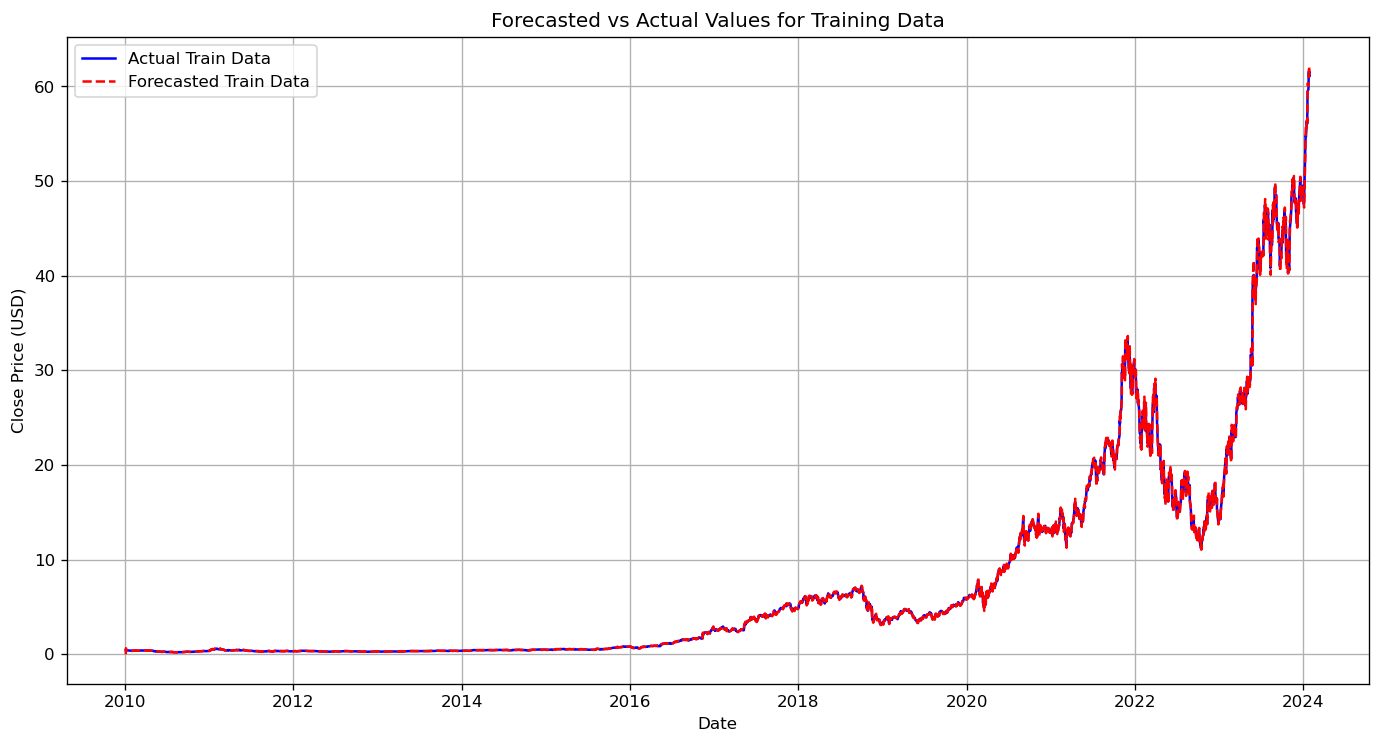

In [178]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Forecast the entire training data period (including the forecasted values)
forecast_train = model_1.predict_in_sample()

# Create a DataFrame to hold forecast results
forecast_train_df = pd.DataFrame({
    'Forecast': forecast_train
}, index=train_df.index)

# Combine train_df and forecast_train_df for plotting
combined_train_df = pd.concat([train_df, forecast_train_df], axis=1)

# Plot results
plt.figure(figsize=(14, 7))

# Plot actual training data
plt.plot(train_df.index, train_df['Close'], label='Actual Train Data', color='blue')

# Plot forecasted values for training data
plt.plot(forecast_train_df.index, forecast_train_df['Forecast'], label='Forecasted Train Data', color='red', linestyle='--')

# Add titles and labels
plt.title('Forecasted vs Actual Values for Training Data')
plt.xlabel('Date')
plt.ylabel('Close Price (USD)')
plt.legend()
plt.grid(True)
plt.show()


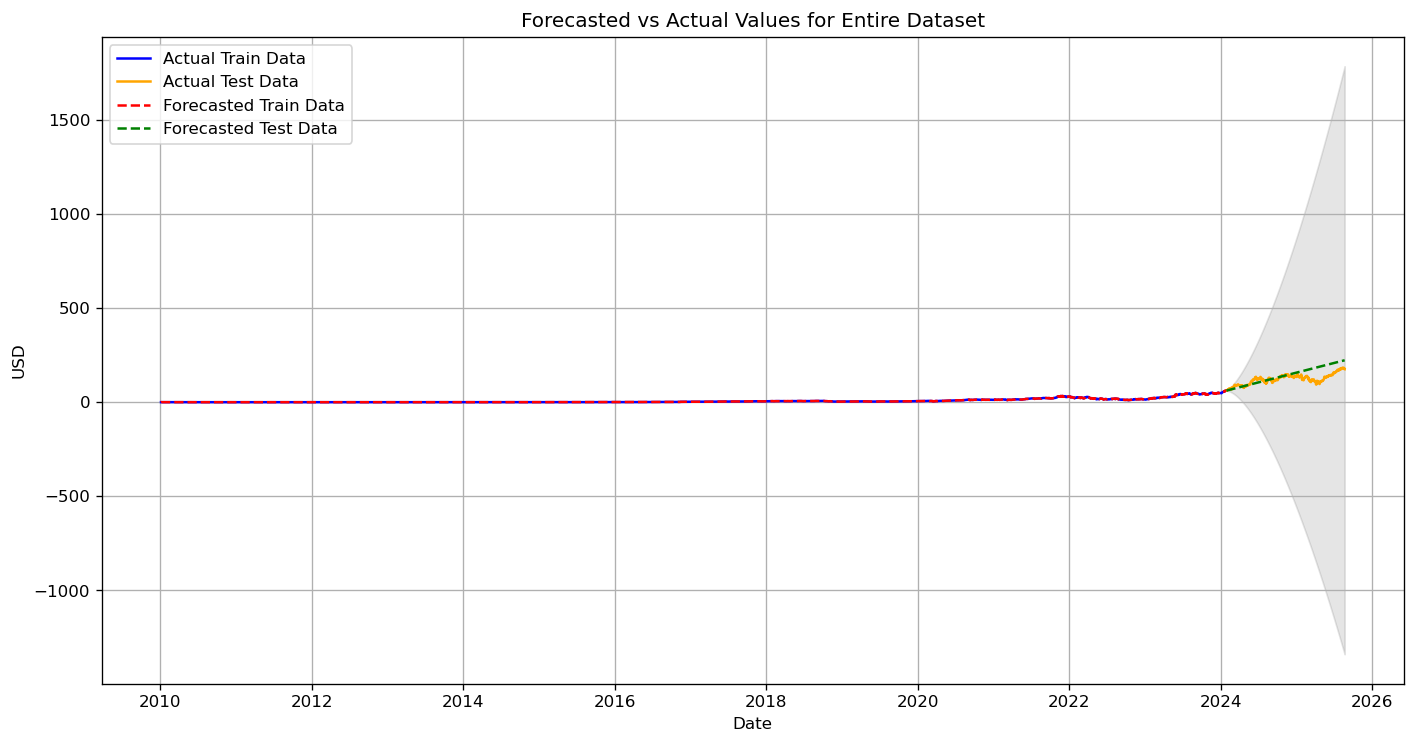

In [179]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Forecast the entire training data period (including the forecasted values)
forecast_train = model_1.predict_in_sample()

# Forecast the test data period
forecast_test, conf_int = model_1.predict(n_periods=len(test_df), return_conf_int=True)

# Create DataFrames to hold forecast results
forecast_train_df = pd.DataFrame({
    'Forecast': forecast_train
}, index=train_df.index)

forecast_test_df = pd.DataFrame({
    'Forecast': forecast_test
}, index=test_df.index)

# Combine train_df, test_df, forecast_train_df, and forecast_test_df for plotting
combined_df = pd.concat([train_df, test_df, forecast_train_df, forecast_test_df], axis=1)

# Plot results
plt.figure(figsize=(14, 7))

# Plot actual data
plt.plot(train_df.index, train_df['Close'], label='Actual Train Data', color='blue')
plt.plot(test_df.index, test_df['Close'], label='Actual Test Data', color='orange')

# Plot forecasted values for training data
plt.plot(forecast_train_df.index, forecast_train_df['Forecast'], label='Forecasted Train Data', color='red', linestyle='--')

# Plot forecasted values for test data
plt.plot(forecast_test_df.index, forecast_test_df['Forecast'], label='Forecasted Test Data', color='green', linestyle='--')

# Add confidence intervals for test data forecast
plt.fill_between(test_df.index, conf_int[:, 0], conf_int[:, 1], color='k', alpha=0.1)

# Add titles and labels
plt.title('Forecasted vs Actual Values for Entire Dataset')
plt.xlabel('Date')
plt.ylabel('USD')
plt.legend()
plt.grid(True)
plt.show()


In [180]:
# Calculate Error Metrics for Auto-ARIMA Model
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Calculate RMSE using the correct column name and forecast variable
rmse = np.sqrt(mean_squared_error(test_df['Close'], forecast_test))
print(f"Auto-ARIMA RMSE: {rmse:.2f}")

# Calculate additional metrics
mae = mean_absolute_error(test_df['Close'], forecast_test)
mape = np.mean(np.abs((test_df['Close'] - forecast_test) / test_df['Close'])) * 100

print(f"Auto-ARIMA MAE: {mae:.2f}")
print(f"Auto-ARIMA MAPE: {mape:.2f}%")

Auto-ARIMA RMSE: 37.45
Auto-ARIMA MAE: 27.71
Auto-ARIMA MAPE: 22.33%


# Model 4: SARIMA

### Seasonal Decomposition

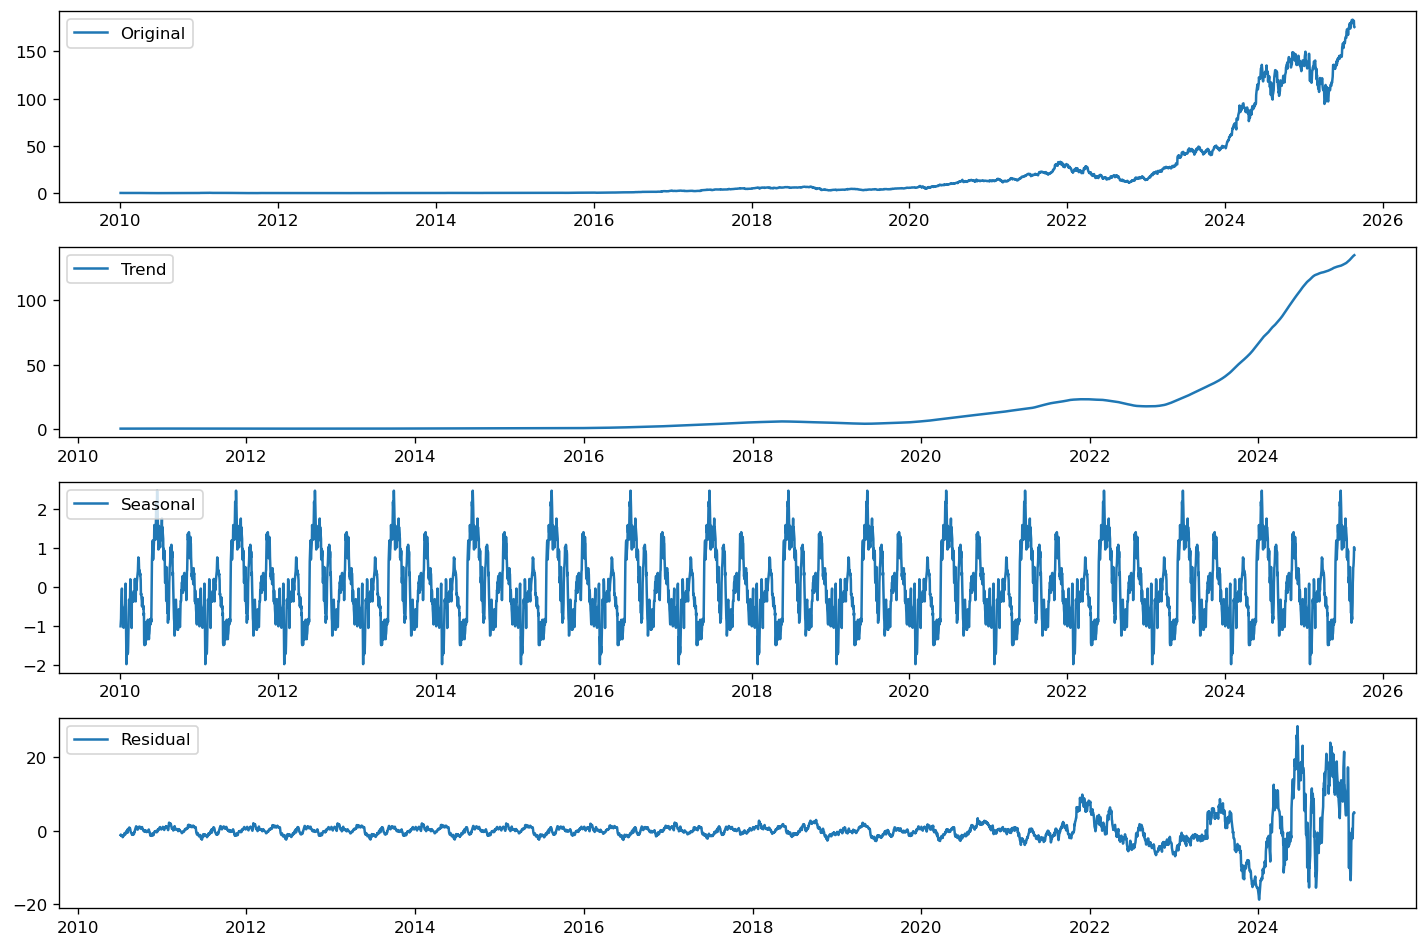

In [181]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Seasonal decomposition on NVIDIA stock closing prices
decomposition = seasonal_decompose(df_ggl['Close'], model='additive', period=365)

plt.figure(figsize=(12, 8))

plt.subplot(411)
plt.plot(df_ggl['Close'], label='Original')
plt.legend(loc='upper left')

plt.subplot(412)
plt.plot(decomposition.trend, label='Trend')
plt.legend(loc='upper left')

plt.subplot(413)
plt.plot(decomposition.seasonal, label='Seasonal')
plt.legend(loc='upper left')

plt.subplot(414)
plt.plot(decomposition.resid, label='Residual')
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()


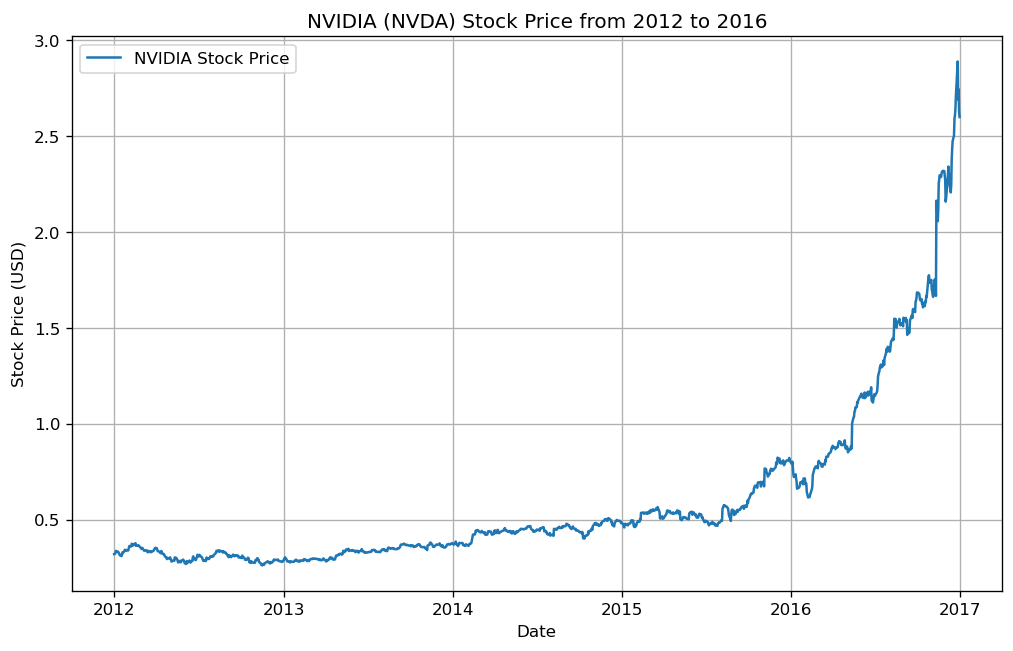

In [182]:
# Filter the DataFrame for the date range between 2012 and 2016
df_filtered = df_ggl.loc['2012-01-01':'2016-12-31']

# Plotting the filtered data
plt.figure(figsize=(10, 6))
plt.plot(df_filtered.index, df_filtered['Close'], label='NVIDIA Stock Price')
plt.title('NVIDIA (NVDA) Stock Price from 2012 to 2016')
plt.xlabel('Date')
plt.ylabel('Stock Price (USD)')
plt.legend()
plt.grid(True)
plt.show()

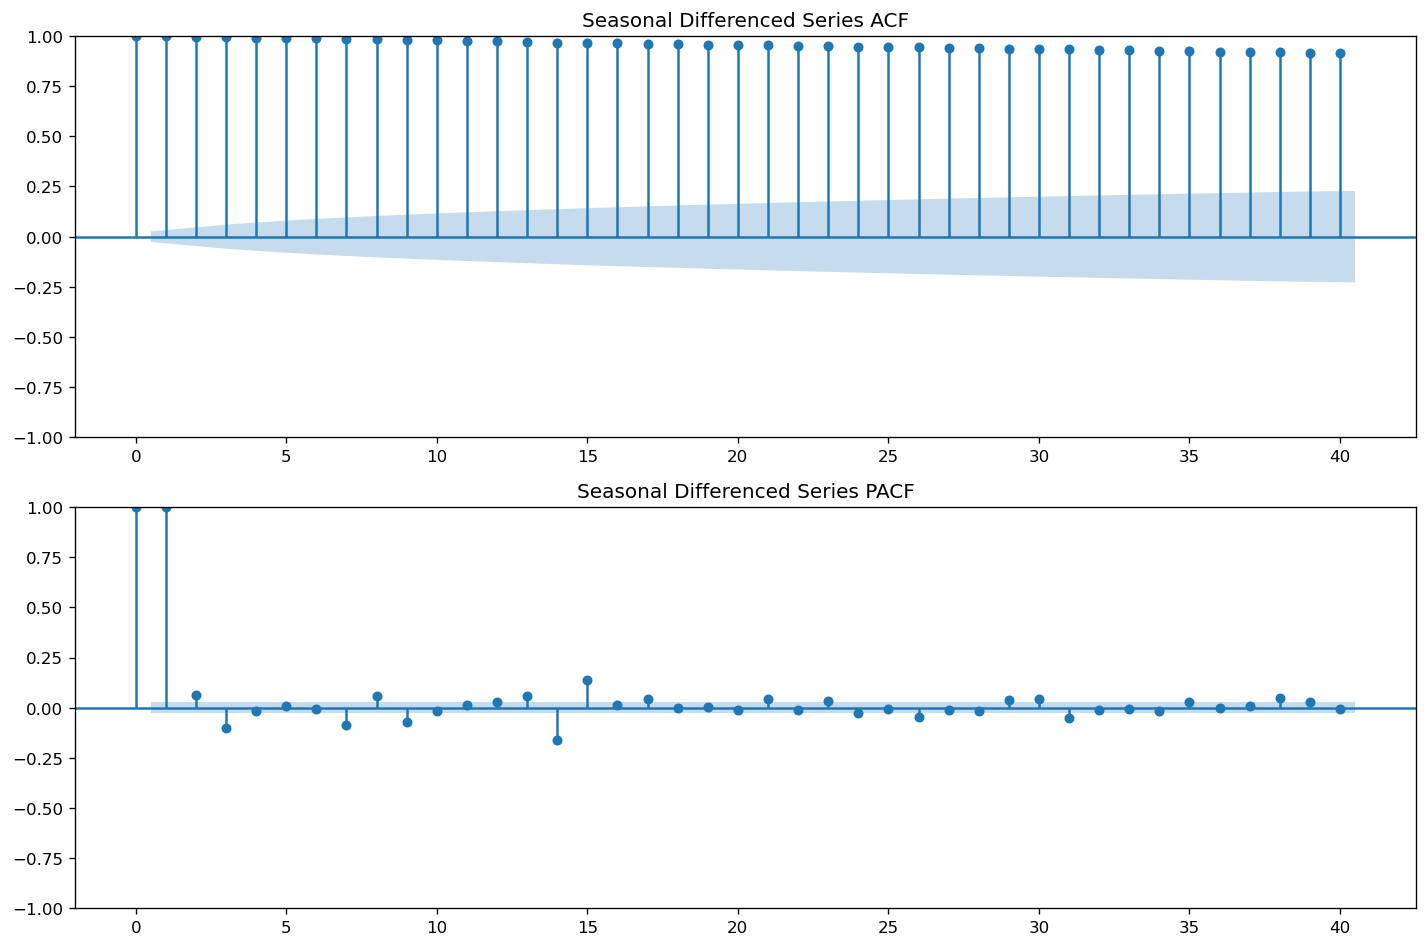

In [183]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Perform seasonal differencing (yearly seasonality for daily data)
seasonal_lag = 365
df_ggl['seasonal_diff'] = df_ggl['Close'].diff(seasonal_lag)

# Plot ACF and PACF for the seasonally differenced series
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(df_ggl['seasonal_diff'].dropna(), lags=40, ax=axes[0])
axes[0].set_title('Seasonal Differenced Series ACF')

plot_pacf(df_ggl['seasonal_diff'].dropna(), lags=40, ax=axes[1])
axes[1].set_title('Seasonal Differenced Series PACF')

plt.tight_layout()
plt.show()


## **Seasonal Differenced Series ACF/PACF Interpretation**

### **📊 ACF Plot (Top) - Short Analysis:**

**Pattern:**
- Sharp drop after lag 0 to confidence bands
- Most correlations within blue shaded area (not significant)
- Gradual decay pattern

**Meaning:**
- ✅ Seasonal differencing removed yearly patterns successfully
- ✅ Series is now stationary
- ✅ No strong autocorrelations remaining

### **📈 PACF Plot (Bottom) - Short Analysis:**

**Pattern:**
- Strong spike at lag 1 (≈1.0)
- Quick cutoff after lag 1
- All other lags within confidence bands

**Meaning:**
- 📍 Direct relationship only with immediate past (1 day)
- 📍 Suggests AR(1) component for SARIMA
- 📍 Clean pattern = good for modeling

### **🎯 SARIMA Model Recommendation:**

**Based on plots:** SARIMA(1,1,1)(1,1,1)[365]
- **AR(1)**: From PACF lag 1 spike
- **I(1)**: Regular differencing
- **MA(1)**: Baseline for error correction
- **Seasonal(1,1,1,365)**: Yearly seasonality

### **💡 Practical Insight:**

**Hinglish mein:**
- Seasonal differencing ke baad series clean ho gayi
- Sirf 1-day lag ka direct effect hai
- NVIDIA stock mein yearly patterns successfully remove ho gaye
- Ab SARIMA model accha perform karega

### Building AUTO SARIMA model

🔍 Running AUTO SARIMA Analysis...
Performing stepwise search to minimize aic
 ARIMA(2,2,2)(1,0,1)[7]             : AIC=inf, Time=4.24 sec
 ARIMA(0,2,0)(0,0,0)[7]             : AIC=5642.714, Time=0.16 sec
 ARIMA(2,2,2)(1,0,1)[7]             : AIC=inf, Time=4.24 sec
 ARIMA(0,2,0)(0,0,0)[7]             : AIC=5642.714, Time=0.16 sec
 ARIMA(1,2,0)(1,0,0)[7]             : AIC=4384.019, Time=0.49 sec
 ARIMA(1,2,0)(1,0,0)[7]             : AIC=4384.019, Time=0.49 sec
 ARIMA(0,2,1)(0,0,1)[7]             : AIC=inf, Time=1.26 sec
 ARIMA(1,2,0)(0,0,0)[7]             : AIC=4392.547, Time=0.20 sec
 ARIMA(0,2,1)(0,0,1)[7]             : AIC=inf, Time=1.26 sec
 ARIMA(1,2,0)(0,0,0)[7]             : AIC=4392.547, Time=0.20 sec
 ARIMA(1,2,0)(2,0,0)[7]             : AIC=4380.960, Time=1.79 sec
 ARIMA(1,2,0)(2,0,0)[7]             : AIC=4380.960, Time=1.79 sec
 ARIMA(1,2,0)(2,0,1)[7]             : AIC=4381.290, Time=2.60 sec
 ARIMA(1,2,0)(2,0,1)[7]             : AIC=4381.290, Time=2.60 sec
 ARIMA(1,2,0)(1,0,1

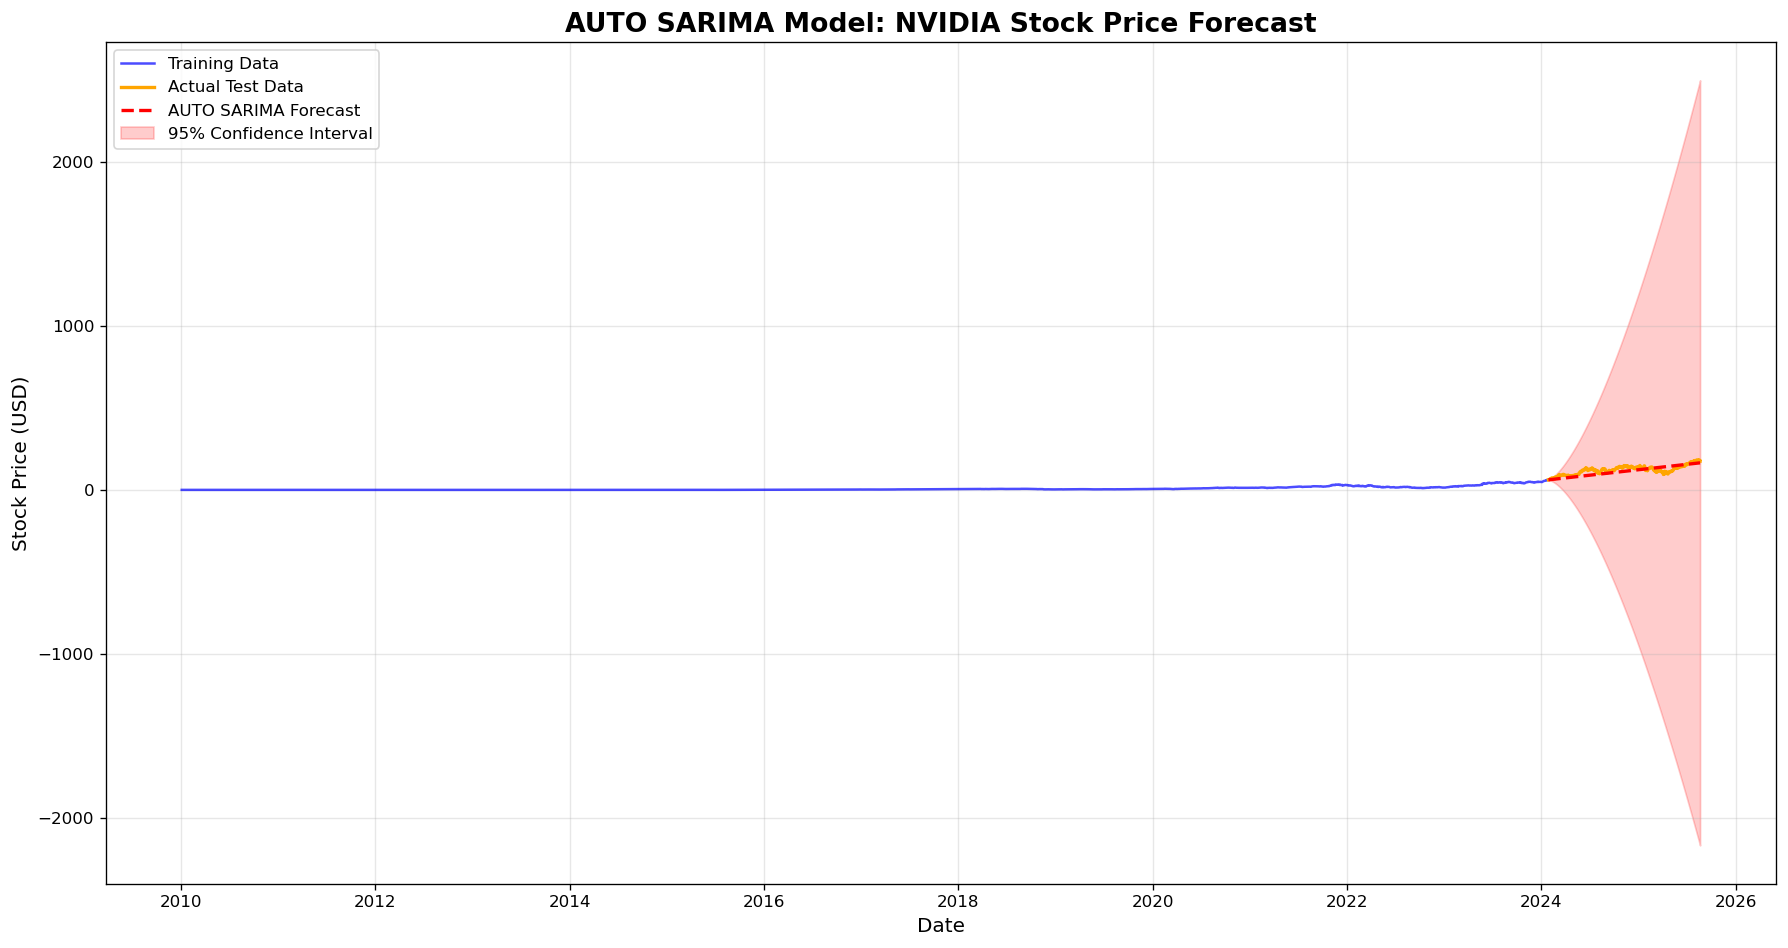


🔧 Selected SARIMA Model: (3, 2, 0) × (2, 0, 0, 7)
📋 Total Parameters: 6
📊 AIC Score: 3579.048
📈 Log-Likelihood: -1783.52


In [184]:
# Fix the import statement and implement proper AUTO SARIMA for NVIDIA stock data

import pmdarima as pm
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Building AUTO SARIMA model for NVIDIA stock data
print("🔍 Running AUTO SARIMA Analysis...")
print("="*60)

# For NVIDIA stock data, use appropriate seasonal parameters
# m=252 (trading days per year) or m=365 (calendar days) or m=7 (weekly patterns)
model_sarima = pm.auto_arima(
    train_df['Close'], 
    seasonal=True, 
    m=7,  # Weekly seasonality (7 days) - more appropriate for daily stock data
    trace=True, 
    suppress_warnings=True,
    max_p=3, max_q=3,  # Limit complexity
    max_P=2, max_Q=2,  # Limit seasonal complexity
    stepwise=True,
    information_criterion='aic'
)

# Print the summary of the best-fit AUTO SARIMA model
print("\n" + "="*60)
print("🏆 BEST AUTO SARIMA MODEL SELECTED:")
print("="*60)
print(model_sarima.summary())

# Generate forecasts for test data
print("\n📈 Generating SARIMA Forecasts...")
forecast_sarima, conf_int_sarima = model_sarima.predict(
    n_periods=len(test_df), 
    return_conf_int=True
)

# Create forecast DataFrame
forecast_sarima_df = pd.DataFrame({
    'Forecast': forecast_sarima
}, index=test_df.index)

# Calculate performance metrics
rmse_sarima = np.sqrt(mean_squared_error(test_df['Close'], forecast_sarima))
mae_sarima = mean_absolute_error(test_df['Close'], forecast_sarima)
mape_sarima = np.mean(np.abs((test_df['Close'] - forecast_sarima) / test_df['Close'])) * 100

print(f"\n📊 AUTO SARIMA Model Performance:")
print(f"RMSE: {rmse_sarima:.2f}")
print(f"MAE: {mae_sarima:.2f}")
print(f"MAPE: {mape_sarima:.2f}%")

# Plot AUTO SARIMA results
plt.figure(figsize=(15, 8))

# Plot training data
plt.plot(train_df.index, train_df['Close'], 
         label='Training Data', color='blue', alpha=0.7)

# Plot test actual data  
plt.plot(test_df.index, test_df['Close'], 
         label='Actual Test Data', color='orange', linewidth=2)

# Plot SARIMA forecast
plt.plot(forecast_sarima_df.index, forecast_sarima_df['Forecast'], 
         label='AUTO SARIMA Forecast', color='red', linestyle='--', linewidth=2)

# Add confidence intervals
plt.fill_between(test_df.index, 
                conf_int_sarima[:, 0], 
                conf_int_sarima[:, 1], 
                color='red', alpha=0.2, label='95% Confidence Interval')

plt.title('AUTO SARIMA Model: NVIDIA Stock Price Forecast', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Stock Price (USD)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Display model details
print(f"\n🔧 Selected SARIMA Model: {model_sarima.order} × {model_sarima.seasonal_order}")
print(f"📋 Total Parameters: {model_sarima.params().shape[0]}")
print(f"📊 AIC Score: {model_sarima.aic():.3f}")
print(f"📈 Log-Likelihood: {model_sarima.arima_res_.llf:.2f}")

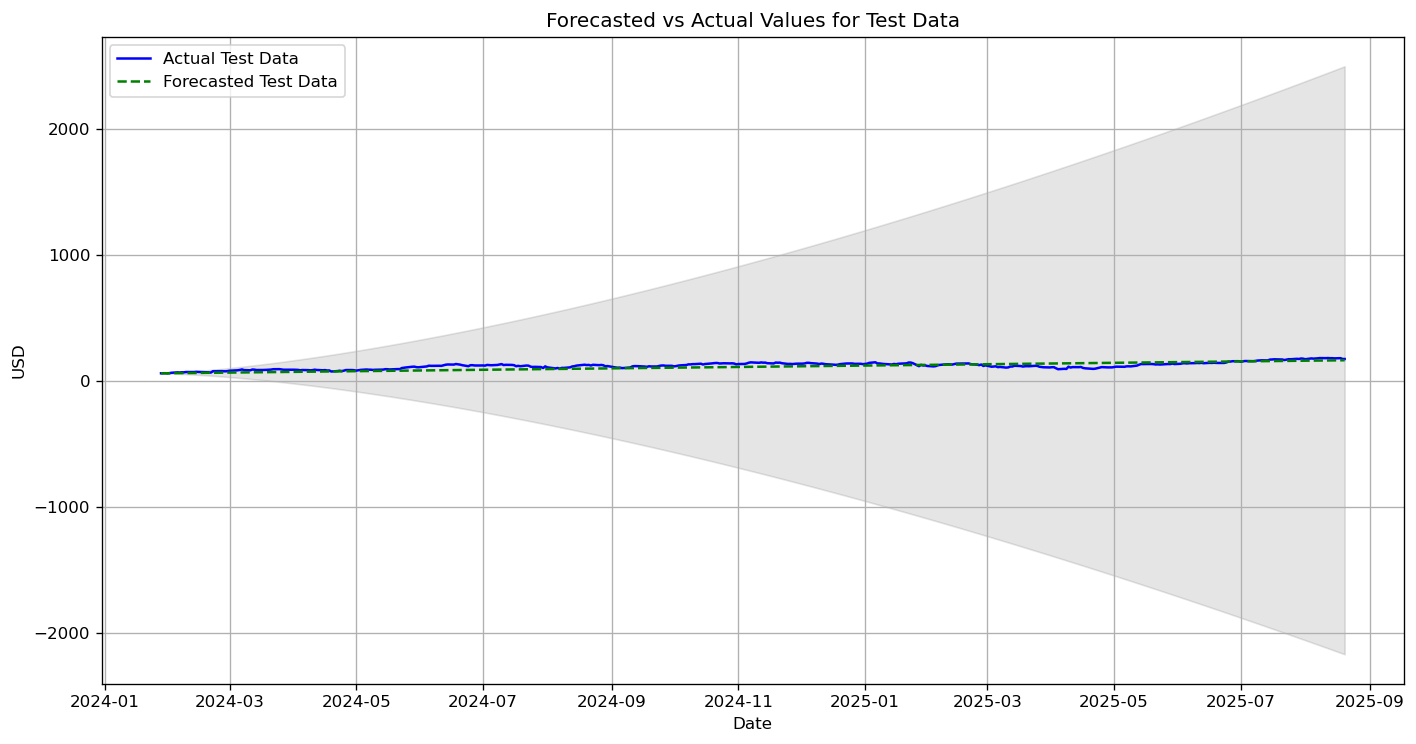

In [185]:
# Generate forecasts using the SARIMA model
forecast_2, forecast_2_conf_int = model_sarima.predict(n_periods=len(test_df), return_conf_int=True)

# Create DataFrames for forecast results
forecast_2_df = pd.DataFrame({
    'Forecast': forecast_2
}, index=test_df.index)

# Convert confidence intervals to DataFrame for easier indexing
forecast_2_conf_int = pd.DataFrame(forecast_2_conf_int, 
                                   columns=['Lower CI', 'Upper CI'], 
                                   index=test_df.index)

# Plot results
plt.figure(figsize=(14, 7))

# Plot actual test data
plt.plot(test_df.index, test_df['Close'], label='Actual Test Data', color='blue')

# Plot forecasted values for test data
plt.plot(forecast_2_df.index, forecast_2_df['Forecast'], label='Forecasted Test Data', color='green', linestyle='--')

# Add confidence intervals for test data forecast
plt.fill_between(test_df.index, forecast_2_conf_int.iloc[:, 0], forecast_2_conf_int.iloc[:, 1], color='k', alpha=0.1)

# Add titles and labels
plt.title('Forecasted vs Actual Values for Test Data')
plt.xlabel('Date')
plt.ylabel('USD')
plt.legend()
plt.grid(True)
plt.show()


In [186]:
# Calculate RMSE and MAE for SARIMA model
rmse = np.sqrt(mean_squared_error(test_df['Close'], forecast_2))
mae = mean_absolute_error(test_df['Close'], forecast_2)

print(f'RMSE: {rmse}')
print(f'MAE: {mae}')

RMSE: 21.295110935037147
MAE: 18.25267895818086


# Model 5: fbprophet

In [187]:
# Create a new DataFrame with 'ds' and 'y' columns
df_fbp = df_ggl[['Close']].reset_index()
df_fbp.columns = ['ds', 'y']

In [188]:
df_fbp.head()

,ds,y
0,2010-01-04,0.423854
1,2010-01-05,0.430044
2,2010-01-06,0.432794
3,2010-01-07,0.424313
4,2010-01-08,0.425230


In [189]:
from prophet import Prophet
from sklearn.metrics import mean_squared_error

# Split the data for Prophet
train_size = int(len(df_fbp) * 0.9)
train = df_fbp.iloc[:train_size]
test = df_fbp.iloc[train_size:]

param_grid = {
    'changepoint_prior_scale': [0.001, 0.01, 0.1],
    'seasonality_prior_scale': [0.01, 0.1, 1],
}
best_params = {}
best_score = float('inf')  # Initialize with a large value

for changepoint_prior_scale in param_grid['changepoint_prior_scale']:
    for seasonality_prior_scale in param_grid['seasonality_prior_scale']:
        model = Prophet(changepoint_prior_scale=changepoint_prior_scale,
                        seasonality_prior_scale=seasonality_prior_scale)
        model.fit(train)

        # Create future dataframe and make predictions
        future = model.make_future_dataframe(periods=len(test))
        forecast = model.predict(future)
        
        # Extract test predictions
        test_predictions = forecast.iloc[-len(test):]['yhat']
        
        # Evaluate the model (e.g., calculate RMSE)
        mse = mean_squared_error(test['y'], test_predictions)

        if mse < best_score:  # Check if current model is better
            best_params = {'changepoint_prior_scale': changepoint_prior_scale,
                           'seasonality_prior_scale': seasonality_prior_scale}
            best_score = mse

print("Best Hyperparameters:", best_params)
print("Best Model Score:", best_score)


22:55:19 - cmdstanpy - INFO - Chain [1] start processing
22:55:20 - cmdstanpy - INFO - Chain [1] done processing
22:55:20 - cmdstanpy - INFO - Chain [1] done processing
22:55:21 - cmdstanpy - INFO - Chain [1] start processing
22:55:21 - cmdstanpy - INFO - Chain [1] start processing
22:55:22 - cmdstanpy - INFO - Chain [1] done processing
22:55:22 - cmdstanpy - INFO - Chain [1] done processing
22:55:23 - cmdstanpy - INFO - Chain [1] start processing
22:55:23 - cmdstanpy - INFO - Chain [1] start processing
22:55:24 - cmdstanpy - INFO - Chain [1] done processing
22:55:24 - cmdstanpy - INFO - Chain [1] done processing
22:55:25 - cmdstanpy - INFO - Chain [1] start processing
22:55:25 - cmdstanpy - INFO - Chain [1] start processing
22:55:25 - cmdstanpy - INFO - Chain [1] done processing
22:55:25 - cmdstanpy - INFO - Chain [1] done processing
22:55:27 - cmdstanpy - INFO - Chain [1] start processing
22:55:27 - cmdstanpy - INFO - Chain [1] start processing
22:55:27 - cmdstanpy - INFO - Chain [1]

Best Hyperparameters: {'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 0.01}
Best Model Score: 6028.305939149981


In [190]:
from prophet import Prophet

# Create the Prophet model with optimal hyperparameters
model = Prophet(
    changepoint_prior_scale=0.001,
    seasonality_prior_scale=0.01
)

# Fit the model to your training data
model.fit(train)

22:55:39 - cmdstanpy - INFO - Chain [1] start processing
22:55:40 - cmdstanpy - INFO - Chain [1] done processing
22:55:40 - cmdstanpy - INFO - Chain [1] done processing


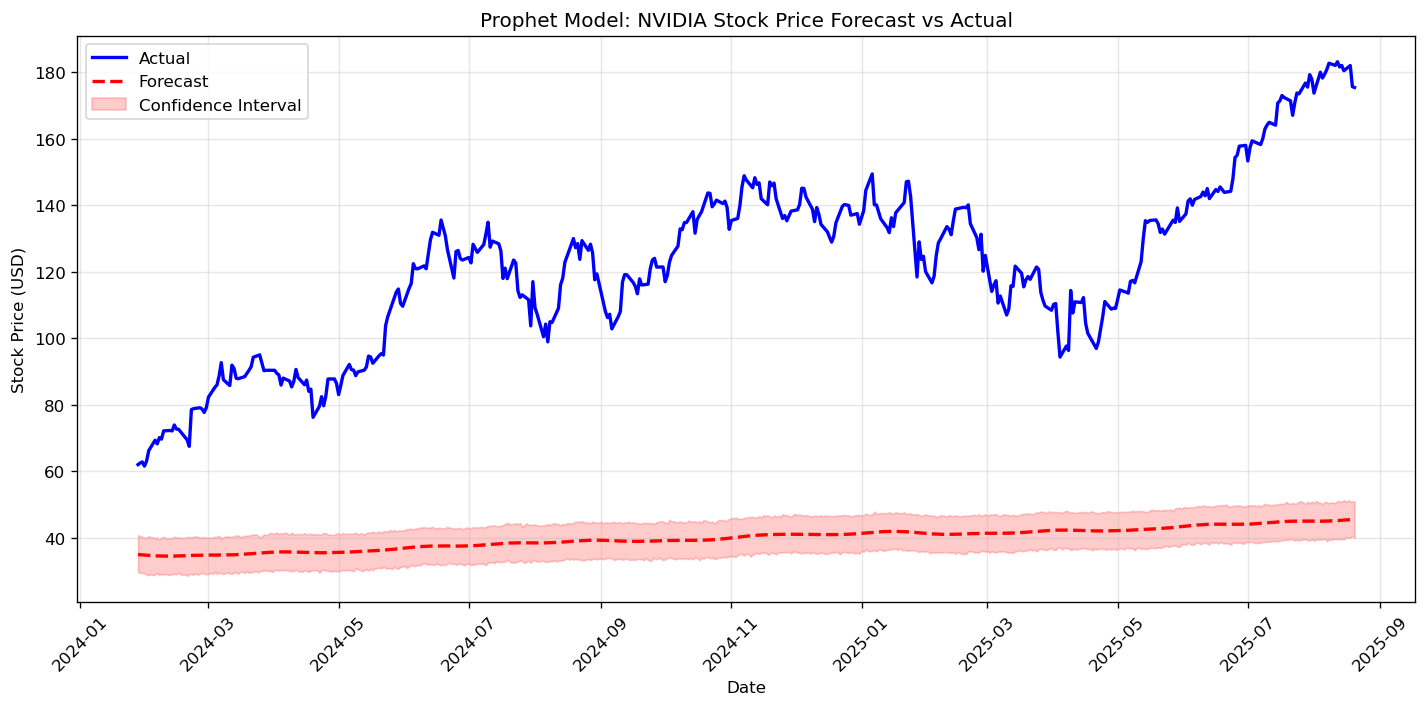

In [191]:
# Generate forecasts using the trained Prophet model
future = model.make_future_dataframe(periods=len(test))
forecast = model.predict(future)

# Extract only the test period forecasts for plotting
test_forecast = forecast.iloc[-len(test):].copy()
test_forecast.index = test.index  # Align indices

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(test['ds'], test['y'], label='Actual', color='blue', linewidth=2)
plt.plot(test['ds'], test_forecast['yhat'], label='Forecast', color='red', linestyle='--', linewidth=2)
plt.fill_between(test['ds'], test_forecast['yhat_lower'], test_forecast['yhat_upper'], 
                 color='red', alpha=0.2, label='Confidence Interval')
plt.xlabel('Date')
plt.ylabel('Stock Price (USD)')
plt.title('Prophet Model: NVIDIA Stock Price Forecast vs Actual')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [192]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse = np.sqrt(mean_squared_error(test['y'], test_forecast['yhat']))
mae = mean_absolute_error(test['y'], test_forecast['yhat'])

print(f'RMSE: {rmse}')
print(f'MAE: {mae}')


RMSE: 85.6153796696191
MAE: 82.2159355857774


# Deep learning Based Approch.

In [193]:
df_ggl.head()

Price,Close,diff,seasonal_diff
2010-01-04,0.423854,NaN,NaN
2010-01-05,0.430044,0.006189,NaN
2010-01-06,0.432794,0.002751,NaN
2010-01-07,0.424313,-0.008482,NaN
2010-01-08,0.425230,0.000917,NaN


In [194]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Use the existing NVIDIA stock data (df_ggl)
# Ensure the data is sorted by date
df_ggl_dl = df_ggl.sort_index()

# Normalize the data using the Close price column
scaler = MinMaxScaler()
df_ggl_scaled = scaler.fit_transform(df_ggl_dl[['Close']])

# Convert the scaled data back to a DataFrame for convenience
df_ggl_scaled = pd.DataFrame(df_ggl_scaled, index=df_ggl_dl.index, columns=['Close'])

# Train-test split
train_size = int(len(df_ggl_scaled) * 0.9)
train_df_dl = df_ggl_scaled.iloc[:train_size]
test_df_dl = df_ggl_scaled.iloc[train_size:]


In [195]:
def create_sequences(data, sequence_length):
    sequences = []
    targets = []
    for i in range(len(data) - sequence_length):
        seq = data[i:i + sequence_length]
        target = data[i + sequence_length]
        sequences.append(seq)
        targets.append(target)
    return np.array(sequences), np.array(targets)

sequence_length = 180

X_train, y_train = create_sequences(train_df_dl['Close'].values, sequence_length)
X_test, y_test = create_sequences(test_df_dl['Close'].values, sequence_length)


In [196]:
import tensorflow as tf
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN

model = Sequential()
model.add(SimpleRNN(50, activation='relu', input_shape=(sequence_length, 1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')

In [197]:
# Reshape data for RNN input
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2)

Epoch 1/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 6.1807e-05 - val_loss: 7.3446e-05
Epoch 2/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 6.1807e-05 - val_loss: 7.3446e-05
Epoch 2/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.0179e-06 - val_loss: 1.1626e-04
Epoch 3/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.0179e-06 - val_loss: 1.1626e-04
Epoch 3/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.0231e-06 - val_loss: 9.3094e-05
Epoch 4/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.0231e-06 - val_loss: 9.3094e-05
Epoch 4/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 9.4446e-07 - val_loss: 2.0567e-04
Epoch 5/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 9.4446e-07 - val_loss: 2.0567e-04
Epoch 5/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.1711e-06 - val_loss: 1.7637e-04
Epoch 6/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 1.1711e-06 - val_loss: 1.7637e-04
Epoch 6/50
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/st

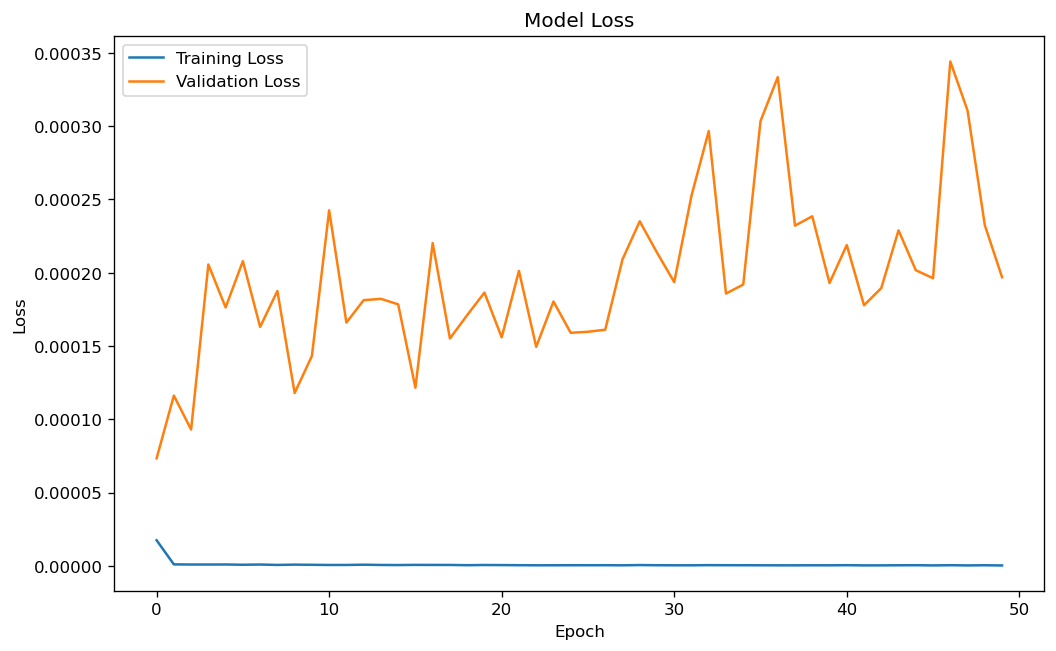

In [198]:
import matplotlib.pyplot as plt

# Plot training & validation loss values
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [199]:
# Make predictions
y_pred = model.predict(X_test)

# Inverse scale the predictions and actual values
y_pred_rescaled = scaler.inverse_transform(y_pred)
y_test_rescaled = scaler.inverse_transform(y_test.reshape(-1, 1))

# Create a DataFrame for comparison
results = pd.DataFrame({'Actual': y_test_rescaled.flatten(), 'Predicted': y_pred_rescaled.flatten()}, index=df_ggl.index[train_size + sequence_length:])

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


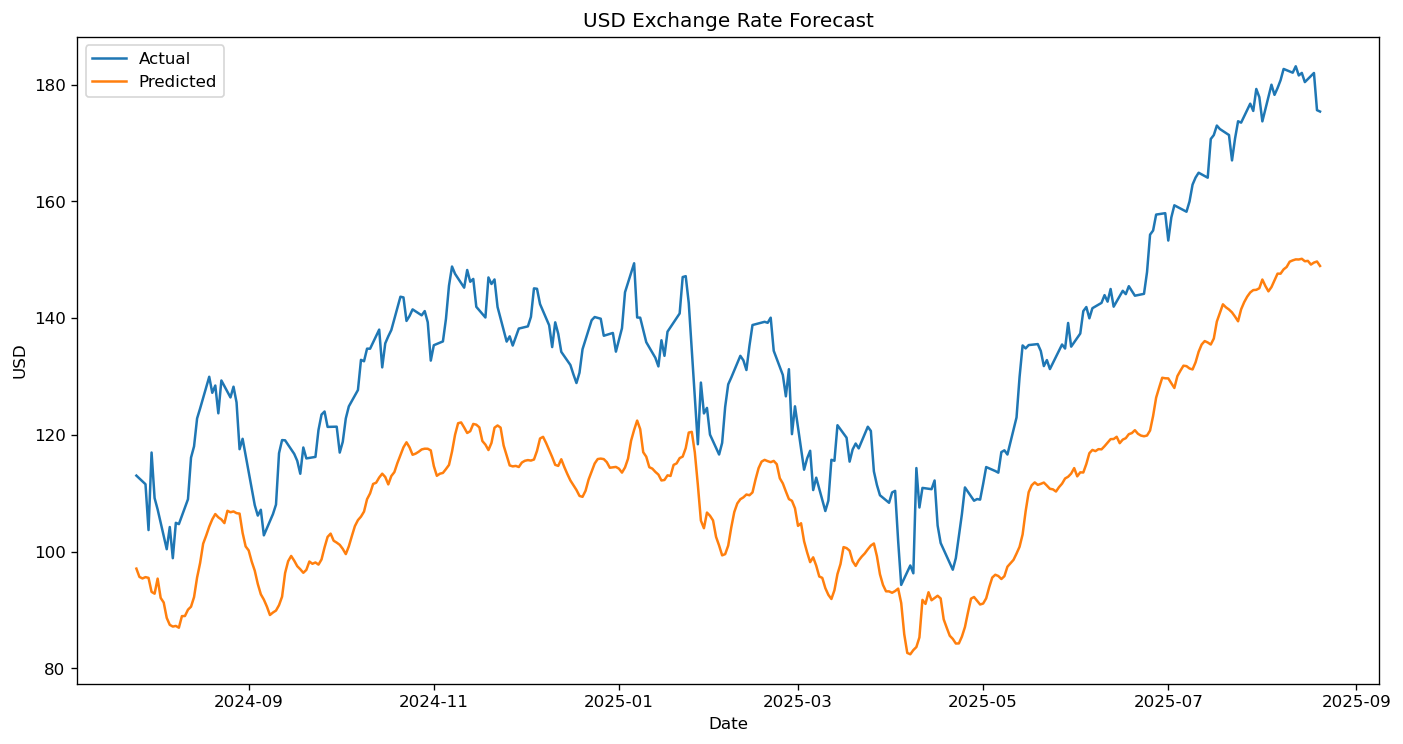

In [200]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
plt.plot(results['Actual'], label='Actual')
plt.plot(results['Predicted'], label='Predicted')
plt.title('USD Exchange Rate Forecast')
plt.xlabel('Date')
plt.ylabel('USD')
plt.legend()
plt.show()

In [201]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse = np.sqrt(mean_squared_error(results['Actual'], results['Predicted']))
mae = mean_absolute_error(results['Actual'], results['Predicted'])

print(f'RMSE: {rmse}')
print(f'MAE: {mae}')


RMSE: 23.059819422428333
MAE: 22.320200790834548


# Model : LSTM

In [202]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense
from keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt

data = df_ggl['Close'].values.reshape(-1, 1)

In [203]:
print(data)

[[  0.42385411]
 [  0.43004355]
 [  0.43279433]
 ...
 [182.00999451]
 [175.63999939]
 [175.3999939 ]]


In [204]:
# Split the data FIRST, then scale separately
train_size = int(len(data) * 0.9)
train_data_raw = data[:train_size]
test_data_raw = data[train_size:]

# Fit scaler only on training data
scaler = MinMaxScaler(feature_range=(0, 1))
train_data = scaler.fit_transform(train_data_raw)

# Transform test data using the same scaler (fitted only on train data)
test_data = scaler.transform(test_data_raw)

print(f"Training data shape: {train_data.shape}")
print(f"Test data shape: {test_data.shape}")


Training data shape: (5137, 1)
Test data shape: (571, 1)


In [205]:
# Create sequences for training and testing
def create_sequences(data, sequence_length):
    X, y = [], []
    for i in range(sequence_length, len(data)):
        X.append(data[i-sequence_length:i, 0])
        y.append(data[i, 0])
    return np.array(X), np.array(y)

sequence_length = 180
X_train, y_train = create_sequences(train_data, sequence_length)
X_test, y_test = create_sequences(test_data, sequence_length)

# Reshape the data for LSTM input
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))


In [206]:
# Build the LSTM model
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(sequence_length, 1)))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')

# Early stopping and model checkpoint
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
model_checkpoint = ModelCheckpoint('best_lstm_model.keras', monitor='val_loss', save_best_only=True)

In [207]:
# Train the model
history = model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.1,
                    callbacks=[early_stopping, model_checkpoint])


Epoch 1/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 13s 73ms/step - loss: 0.0021 - val_loss: 8.2274e-04
Epoch 2/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 13s 73ms/step - loss: 0.0021 - val_loss: 8.2274e-04
Epoch 2/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 71ms/step - loss: 9.3515e-05 - val_loss: 0.0028
Epoch 3/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 71ms/step - loss: 9.3515e-05 - val_loss: 0.0028
Epoch 3/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 71ms/step - loss: 7.2431e-05 - val_loss: 0.0015
Epoch 4/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 71ms/step - loss: 7.2431e-05 - val_loss: 0.0015
Epoch 4/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 71ms/step - loss: 7.2074e-05 - val_loss: 0.0022
Epoch 5/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 71ms/step - loss: 7.2074e-05 - val_loss: 0.0022
Epoch 5/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 71ms/step - loss: 5.6874e-05 - val_loss: 8.8199e-04
Epoch 6/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 71ms/step - loss: 5.6874e-05 - val_loss: 8.8199e-04
Epoch 6/100
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 72ms/step - loss:

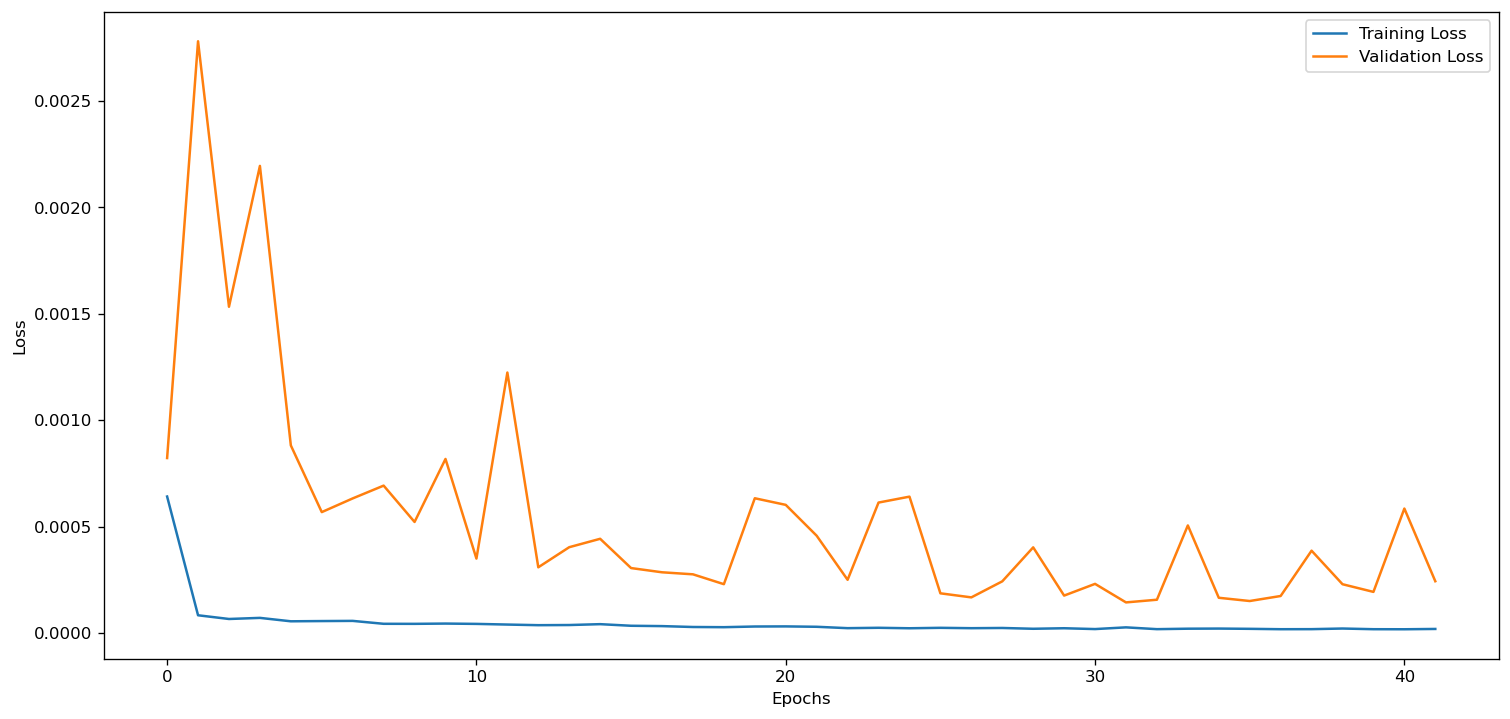

In [208]:
# Plot training and validation loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [209]:
# Make predictions on the test data
predicted_values = model.predict(X_test)

# Invert scaling for predictions
predicted_values = scaler.inverse_transform(predicted_values.reshape(-1, 1))
y_test_scaled = scaler.inverse_transform(y_test.reshape(-1, 1))


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step


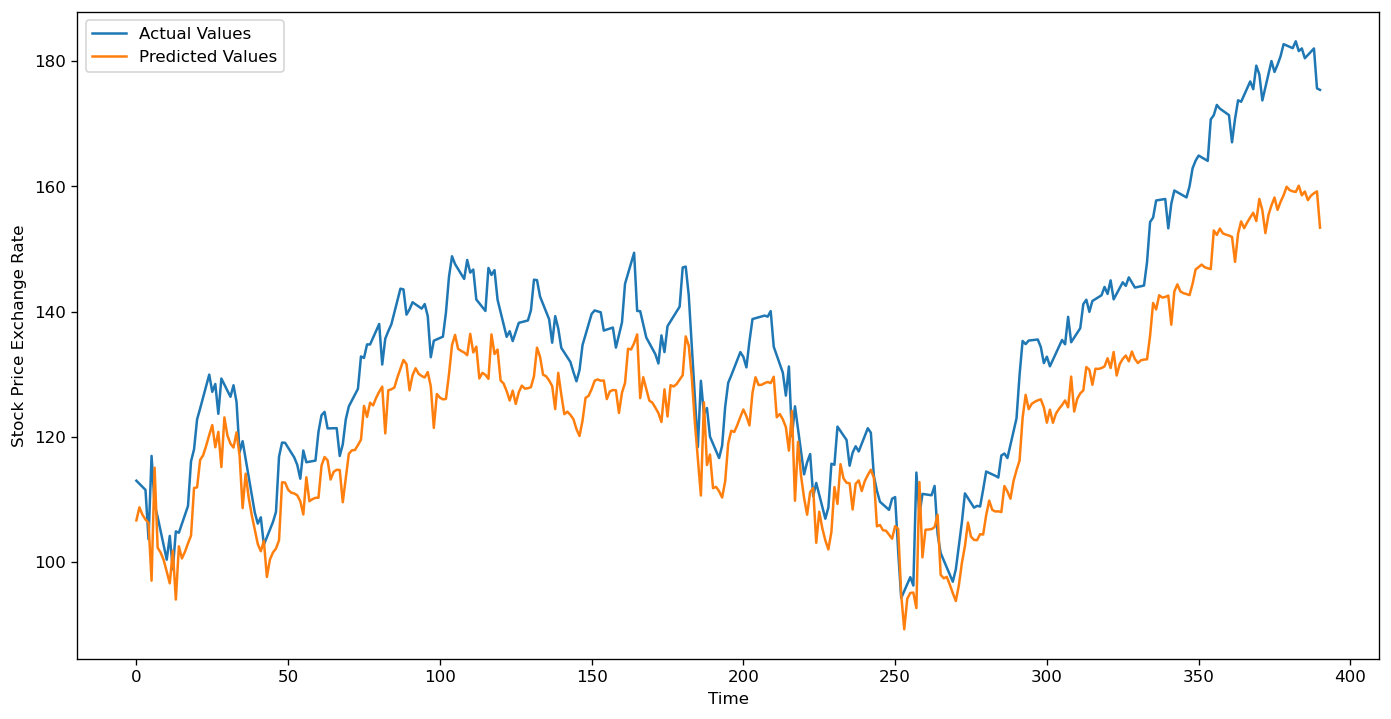

In [210]:
# Plot the actual and predicted values
plt.figure(figsize=(14, 7))
plt.plot(y_test_scaled, label='Actual Values')
plt.plot(predicted_values, label='Predicted Values')
plt.xlabel('Time')
plt.ylabel('Stock Price Exchange Rate')
plt.legend()
plt.show()


173/173 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step
173/173 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step


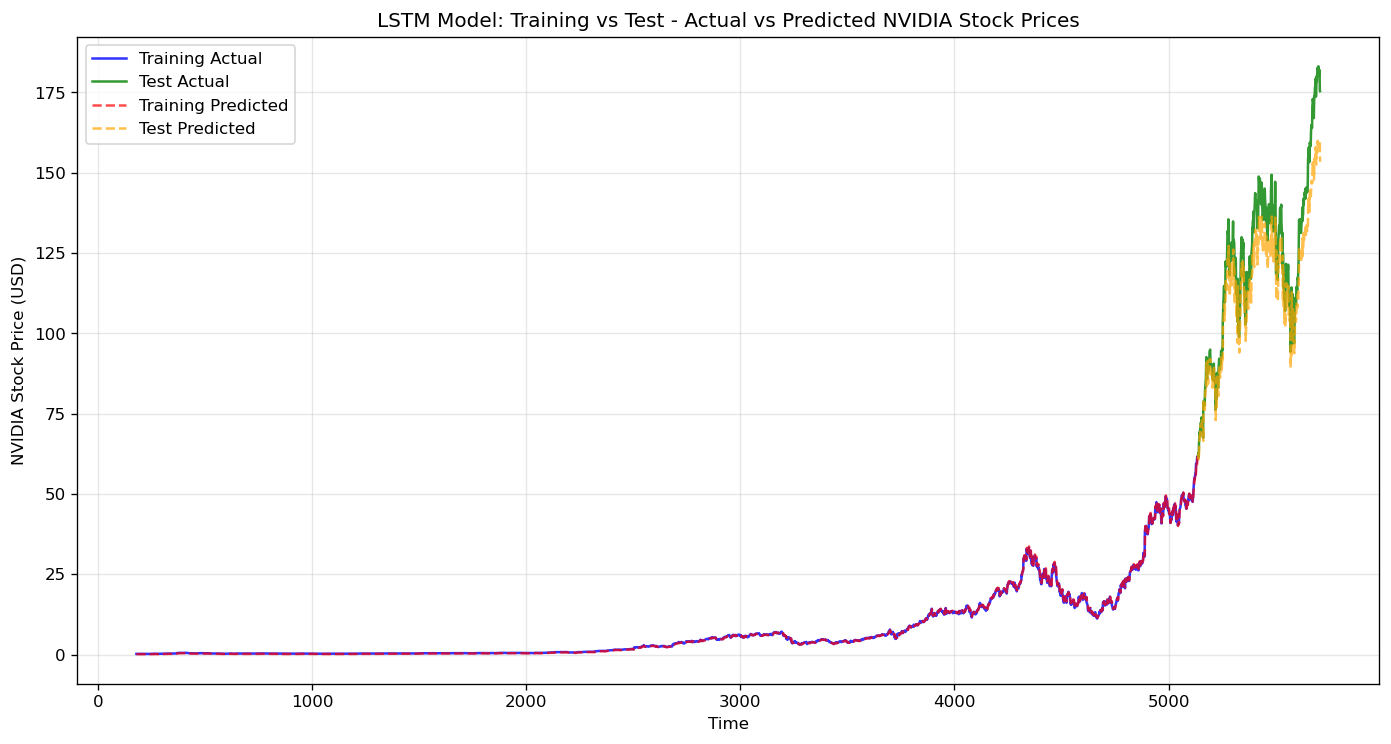

In [211]:
# Make predictions on the entire dataset
def make_predictions(model, data, sequence_length):
    X, _ = create_sequences(data, sequence_length)
    X = X.reshape((X.shape[0], X.shape[1], 1))
    predictions = model.predict(X)
    return predictions

# Combine train and test data for full dataset predictions
full_scaled_data = np.concatenate([train_data, test_data], axis=0)

# Get predictions for the entire dataset
full_data_predictions = make_predictions(model, full_scaled_data, sequence_length)

# Invert scaling for predictions and actual values
full_data_predictions = scaler.inverse_transform(full_data_predictions.reshape(-1, 1))

# Combine training and testing predictions
full_data_actual = scaler.inverse_transform(full_scaled_data)

# Calculate split points
train_end = len(train_data) - sequence_length
test_start = train_end

# Plot the actual and predicted values for the entire dataset
plt.figure(figsize=(14, 7))

# Plot training data (actual)
plt.plot(np.arange(sequence_length, train_end + sequence_length), 
         full_data_actual[sequence_length:train_end + sequence_length], 
         label='Training Actual', color='blue', alpha=0.8)

# Plot test data (actual)
plt.plot(np.arange(train_end + sequence_length, len(full_data_actual)), 
         full_data_actual[train_end + sequence_length:], 
         label='Test Actual', color='green', alpha=0.8)

# Plot training predictions
plt.plot(np.arange(sequence_length, train_end + sequence_length), 
         full_data_predictions[:train_end], 
         label='Training Predicted', color='red', linestyle='--', alpha=0.7)

# Plot test predictions
plt.plot(np.arange(train_end + sequence_length, train_end + sequence_length + len(full_data_predictions[train_end:])), 
         full_data_predictions[train_end:], 
         label='Test Predicted', color='orange', linestyle='--', alpha=0.7)

plt.xlabel('Time')
plt.ylabel('NVIDIA Stock Price (USD)')
plt.title('LSTM Model: Training vs Test - Actual vs Predicted NVIDIA Stock Prices')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [212]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test_scaled, predicted_values))
print(f'Root Mean Squared Error: {rmse}')

# Calculate MAE
mae = mean_absolute_error(y_test_scaled, predicted_values)
print(f'Mean Absolute Error: {mae}')


Root Mean Squared Error: 11.420798480174023
Mean Absolute Error: 10.07854083127073
